
# BrainBridge — Notebook de Analise do Modelo (Self-Contained)
Notebook autossuficiente para treinamento e avaliacao de EEG/EMG estilo OpenBCI.

**Inclui:**
- Curvas de loss e accuracy (treino/val)
- Matriz de confusao no teste
- F1-score (weighted) e accuracy
- Pipeline: leitura CSV (OpenBCI-like), janelas T1/T2 -> T0, filtro Butterworth 8-30 Hz, z-score por janela
- Modelo CNN 1D simples (Keras)

> Basta subir seus CSVs numa pasta no Colab e ajustar as variaveis de configuracao.


In [1]:

# Rode isto no Colab se faltar algo
# %pip install -q numpy pandas matplotlib scikit-learn scipy tensorflow


In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:

import os, sys, glob, csv, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score, precision_score, recall_score

# scipy para filtros
from scipy.signal import butter, filtfilt

# tensorflow / keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# matplotlib inline (quando aplicavel)
%matplotlib inline


In [4]:
# ==== CONFIGURACAO ====
# Detectar automaticamente o ambiente e caminho de dados
import os

# Tentar caminhos locais primeiro
LOCAL_DATA_PATHS = [
    "C:\\Users\\Chari\\Documents\\dev\\Brainbridge\\tools\\downloader\\data\\MNE-eegbci-data\\files\\eegmmidb\\1.0.0",
    "/content/drive/MyDrive/Colab Notebooks/1.0.0",  # Colab
]

DATA_DIR = None
for path in LOCAL_DATA_PATHS:
    if os.path.exists(path):
        DATA_DIR = path
        print(f"✓ Dados encontrados em: {DATA_DIR}")
        break

if DATA_DIR is None:
    print("⚠️ AVISO: Nenhum caminho de dados encontrado!")
    print("Caminhos tentados:")
    for path in LOCAL_DATA_PATHS:
        print(f"  - {path}")
    print("\nAjuste LOCAL_DATA_PATHS com o caminho correto dos seus CSVs")
    DATA_DIR = LOCAL_DATA_PATHS[0]  # fallback

PATTERN  = "S*/*.csv"       # padrao dos arquivos (inclui subpastas S*)
FS       = 125.0         # Hz
WINDOW_SIZE = 250        # amostras (~2s a 125 Hz)
STEP        = 50        # amostras (50% overlap)
BAND        = (0.5, 50.0)  # Hz (faixa de interesse)
EPOCHS      = 200
BATCH_SIZE  = 32
TEST_SIZE   = 0.2
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

✓ Dados encontrados em: C:\Users\Chari\Documents\dev\Brainbridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0


In [5]:

class ButterworthFilter:
    def __init__(self, lowcut: float, highcut: float, fs: float, order: int = 6):
        self.low = lowcut
        self.high = highcut
        self.fs = fs
        self.order = order
        nyq = 0.5 * fs
        low = lowcut / nyq if lowcut and lowcut > 0 else 0.0
        high = highcut / nyq if highcut and highcut > 0 else 1.0
        if high <= 0 or high > 1.0:
            high = 0.999
        if low <= 0:
            btype = "lowpass"
            Wn = high
        elif high >= 1.0:
            btype = "highpass"
            Wn = low
        else:
            btype = "bandpass"
            Wn = [low, high]
        self.b, self.a = butter(order, Wn, btype=btype, analog=False)

    def apply_filter(self, data: np.ndarray) -> np.ndarray:
        """Aplica filtfilt em cada canal.
        Espera-se data como (n_channels, n_samples) ou (n_samples,) para 1 canal.
        Retorna shape igual ao de entrada.
        """
        x = np.asarray(data)
        if x.ndim == 1:
            return filtfilt(self.b, self.a, x)
        if x.ndim == 2:
            out = np.zeros_like(x, dtype=np.float32)
            for i in range(x.shape[0]):
                out[i] = filtfilt(self.b, self.a, x[i])
            return out
        raise ValueError("apply_filter: data deve ser 1D ou 2D")


In [6]:

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1w = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    return {
        "accuracy": float(acc),
        "f1_score": float(f1w),
        "precision": float(prec),
        "recall": float(rec),
    }


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam


def build_cnn_1d(input_shape, num_classes=2, architecture="EEGNET", hyperparameters={}):
    """
    Builds different CNN architectures based on the 'architecture' parameter.
    """
    if architecture == "EEGNET":
        # implementação simplificada
        # input_shape = hyperparameters.get('input_shape', (250, 16)) # Using the provided input_shape
        # num_classes = hyperparameters.get('num_classes', 2) # Using the provided num_classes

        model = Sequential()
        model.add(Conv1D(filters=16, kernel_size=64, padding='same', input_shape=input_shape))
        model.add(BatchNormalization())
        model.add(Conv1D(filters=32, kernel_size=1))
        model.add(BatchNormalization())
        model.add(layers.Activation('elu'))
        model.add(MaxPooling1D(pool_size=4))
        model.add(Dropout(0.25))

        model.add(Conv1D(filters=32, kernel_size=16, padding='same', groups=32))
        model.add(Conv1D(filters=32, kernel_size=1))
        model.add(BatchNormalization())
        model.add(layers.Activation('elu'))
        model.add(MaxPooling1D(pool_size=8))
        model.add(Dropout(0.25))

        model.add(Flatten())
        model.add(Dense(num_classes, activation='softmax'))

        model.compile(optimizer=Adam(learning_rate=hyperparameters.get('learning_rate', 0.0001)), # Reduced learning rate
                      loss='sparse_categorical_crossentropy', # Changed to sparse_categorical_crossentropy
                      metrics=['accuracy'])

        return model
    elif architecture == "SIMPLE_CNN_1D":
        inputs = keras.Input(shape=input_shape)
        x = layers.Conv1D(32, 7, padding="same", activation="relu")(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dropout(0.3)(x)
        outputs = layers.Dense(num_classes, activation="softmax")(x)
        model = keras.Model(inputs, outputs)
        model.compile(optimizer=keras.optimizers.Adam(1e-3),
                      loss="sparse_categorical_crossentropy",
                      metrics=["accuracy"])
        return model
    else:
        raise ValueError(f"Unknown architecture: {architecture}")

In [8]:
def load_openbci_csv(csv_path: str):
    """Carrega CSV estilo OpenBCI.
    Retorna:
      data: np.ndarray (n_samples, 16) com EXG0..EXG15
      markers: lista de strings com anotacoes (ex: "T1", "T2", "T0" ou "")
    """
    rows = []
    with open(csv_path, "r", newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:
                continue
            if row[0].startswith("%"):
                continue
            if row[0] == "Sample Index":
                continue
            rows.append(row)

    data = []
    markers = []
    for r in rows:
        if len(r) < 17:
            continue
        try:
            chans = [float(x) for x in r[1:17]]  # EXG0..EXG15 nas colunas 1..16
        except Exception:
            continue
        data.append(chans)
        markers.append(r[-1] if len(r) > 0 else "")
    return np.array(data, dtype=np.float32), markers


def find_marker_indices(markers):
    idxs = {"T0": [], "T1": [], "T2": []}
    for i, m in enumerate(markers):
        if m in idxs:
            idxs[m].append(i)
    return idxs


def segments_between(data: np.ndarray, start_idx: list, end_idx: list):
    segs = []
    for s in start_idx:
        e = next((x for x in end_idx if x > s), None)
        if e is None:
            continue
        seg = data[s:e]
        if len(seg) > 0:
            segs.append(seg)
    return segs


def create_windows_openbci(csv_files, fs=125.0, window_size=250, step=125):
    """Extrai janelas rotuladas: T1..T0 => 0; T2..T0 => 1.
    Retorna X (n_samples, window_size, 16) e y (n_samples,).
    """
    X_list, y_list = [], []

    for path in csv_files:
        data, markers = load_openbci_csv(path)
        if data.size == 0:
            continue
        idxs = find_marker_indices(markers)
        seg_T1 = segments_between(data, idxs.get("T1", []), idxs.get("T0", []))
        seg_T2 = segments_between(data, idxs.get("T2", []), idxs.get("T0", []))

        def add_windows(seg_list, label):
            nonlocal X_list, y_list
            for seg in seg_list:
                n = len(seg)
                if n < window_size:
                    continue
                for start in range(0, n - window_size + 1, step):
                    w = seg[start:start+window_size]              # (win, ch=16)
                    X_list.append(w.astype(np.float32))
                    y_list.append(label)

        add_windows(seg_T1, 0)
        add_windows(seg_T2, 1)

    if not X_list:
        return np.zeros((0, window_size, 16), dtype=np.float32), np.zeros((0,), dtype=np.int32)
    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int32)
    return X, y

# New preprocessing functions
from scipy.signal import sosfiltfilt

def bandpass_05_50_sos(sig, fs=125.0, low=0.5, high=50.0, order=4):
    """
    sig: (T, C) ou (N, T, C)
    fs: 125 Hz
    Faixa: 0.5–50 Hz (zero-phase)
    """
    nyq = fs / 2.0
    # margem de segurança porque 50 Hz está perto do Nyquist=62.5
    high = min(high, nyq - 1.0)   # 49.0 se fs=125
    low = max(low, 0.05)          # evita cutoff muito colado em 0

    sos = butter(order, [low/nyq, high/nyq], btype="bandpass", output="sos")

    if sig.ndim == 2:
        # (T, C)
        return sosfiltfilt(sos, sig, axis=0)
    elif sig.ndim == 3:
        # (N, T, C) -> aplica janela a janela
        out = np.empty_like(sig, dtype=np.float32)
        for i in range(sig.shape[0]):
            out[i] = sosfiltfilt(sos, sig[i], axis=0)
        return out
    else:
        raise ValueError("Esperado (T, C) ou (N, T, C)")

def preprocess_X_bandpass_only(X, fs=125.0):
    """
    X: (N, T, C)
    Passos:
      1) bandpass 0.5–50 Hz (zero-phase)
    """
    Xp = bandpass_05_50_sos(X.astype(np.float32), fs=fs, low=0.5, high=50.0, order=4)
    return Xp

def fit_channel_stats(X_train):
    # z-score por canal usando treino (eixo batch+tempo)
    mu = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
    sd = X_train.reshape(-1, X_train.shape[-1]).std(axis=0) + 1e-8
    return mu, sd

def apply_channel_stats(X, mu, sd):
    return (X - mu) / sd

In [9]:
# ==== CARREGAMENTO E PREPARAÇÃO DE DADOS ====
print("="*80)
print("CARREGAMENTO DE DADOS")
print("="*80)
print(f"Buscando CSVs em: {DATA_DIR}")
print(f"Padrão: {PATTERN}")
print()

csv_files = sorted(glob.glob(str(Path(DATA_DIR) / PATTERN)))
print(f"✓ CSVs encontrados: {len(csv_files)}")

if not csv_files:
    print("❌ ERRO: Nenhum CSV encontrado!")
    print("\nDiagnóstico:")
    print(f"  DATA_DIR existe? {os.path.exists(DATA_DIR)}")
    if os.path.exists(DATA_DIR):
        subdirs = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
        print(f"  Subdiretórios em DATA_DIR: {subdirs[:10]}")
    raise RuntimeError(f"Nenhum CSV encontrado em {DATA_DIR}")
else:
    print("Primeiros 10 arquivos:")
    for f in csv_files[:10]:
        print(f"  - {f}")

# Criar janelas
print()
print(f"Criando janelas (window_size={WINDOW_SIZE}, step={STEP})...")
X_raw, y = create_windows_openbci(csv_files, fs=FS, window_size=WINDOW_SIZE, step=STEP)
print(f"✓ X_raw shape: {X_raw.shape}")
print(f"✓ y shape: {y.shape}")
print(f"✓ Classes: {np.unique(y, return_counts=True)}")
print()

if len(X_raw) == 0:
    print("❌ ERRO: Nenhuma janela foi extraída!")
    print("\nDiagnóstico possível:")
    print("  - CSVs não têm os marcadores T1/T2/T0?")
    print("  - Janelas têm menos amostras que window_size?")
    print("  - Formato de CSV diferente do esperado?")
    raise RuntimeError("Dados insuficientes para treino/avaliacao (nenhuma janela extraída).")

if len(np.unique(y)) < 2:
    print("❌ ERRO: Menos de 2 classes encontradas!")
    print(f"   Classes encontradas: {np.unique(y)}")
    raise RuntimeError("Dados insuficientes para treino/avaliacao (precisa de 2 classes).")

# Apply bandpass filter
print(f"Aplicando filtro bandpass (0.5-50 Hz)...")
X_bandpass = preprocess_X_bandpass_only(X_raw, fs=FS)
print(f"✓ X_bandpass shape: {X_bandpass.shape}")
print()

X_train, X_test, y_train, y_test = train_test_split(
    X_bandpass, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
)

print(f"Split treino/teste:")
print(f"  X_train: {X_train.shape} | y_train classes: {np.unique(y_train, return_counts=True)}")
print(f"  X_test:  {X_test.shape} | y_test classes:  {np.unique(y_test, return_counts=True)}")
print()

print(f"Aplicando normalização z-score por canal...")
mu, sd = fit_channel_stats(X_train)
X_train_processed = apply_channel_stats(X_train, mu, sd)
X_test_processed = apply_channel_stats(X_test, mu, sd)

print(f"✓ X_train_processed shape: {X_train_processed.shape}")
print(f"✓ X_test_processed shape: {X_test_processed.shape}")
print()

CARREGAMENTO DE DADOS
Buscando CSVs em: C:\Users\Chari\Documents\dev\Brainbridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0
Padrão: S*/*.csv

✓ CSVs encontrados: 172
Primeiros 10 arquivos:
  - C:\Users\Chari\Documents\dev\Brainbridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R04_csv_openbci.csv
  - C:\Users\Chari\Documents\dev\Brainbridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R08_csv_openbci.csv
  - C:\Users\Chari\Documents\dev\Brainbridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R12_csv_openbci.csv
  - C:\Users\Chari\Documents\dev\Brainbridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R04_csv_openbci.csv
  - C:\Users\Chari\Documents\dev\Brainbridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R08_csv_openbci.csv
  - C:\Users\Chari\Documents\dev\Brainbridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R12_csv_openbci.c

In [10]:

# ==== CONSTRUÇÃO E TREINAMENTO DO MODELO ====
print("Construindo modelo CNN 1D...")
model = build_cnn_1d(input_shape=(X_train_processed.shape[1], X_train_processed.shape[2]), num_classes=2)
print("✓ Modelo construído com sucesso!")
print()

# Add Early Stopping callback
print("Iniciando treinamento...")
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

hist = model.fit(
    X_train_processed, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[early_stopping]
)
print("\n✓ Treinamento concluído!")


Construindo modelo CNN 1D...


C:\Users\Chari\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✓ Modelo construído com sucesso!

Iniciando treinamento...
Epoch 1/200
434/434 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.4933 - loss: 1.0607 - val_accuracy: 0.5032 - val_loss: 0.7428
Epoch 2/200
434/434 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.4933 - loss: 1.0607 - val_accuracy: 0.5032 - val_loss: 0.7428
Epoch 2/200
434/434 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5009 - loss: 0.9263 - val_accuracy: 0.5072 - val_loss: 0.7244
Epoch 3/200
434/434 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5009 - loss: 0.9263 - val_accuracy: 0.5072 - val_loss: 0.7244
Epoch 3/200
434/434 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5055 - loss: 0.8554 - val_accuracy: 0.4957 - val_loss: 0.7151
Epoch 4/200
434/434 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5055 - loss: 0.8554 - val_accuracy: 0.4957 - val_loss: 0.7151
Epoch 4/200
434/434 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5051 - loss: 0.8152 - val_accuracy: 0.5014 - val_loss: 0.7054
Epoch 5/200
434/434 ━━━━━━━━━

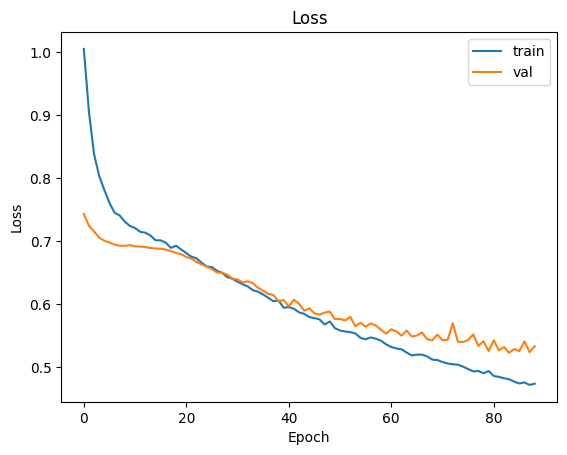

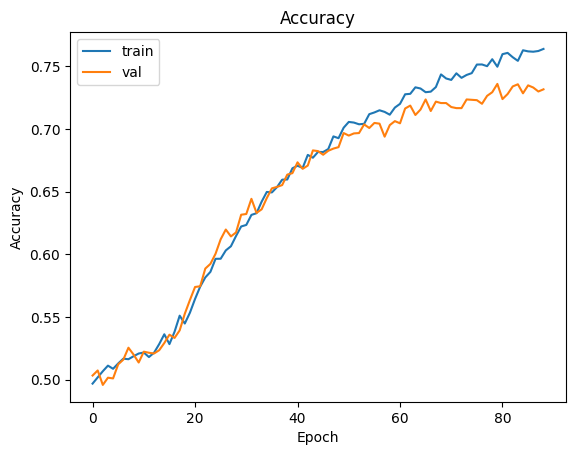

In [11]:

# Curva de Loss
plt.figure()
plt.plot(hist.history.get("loss", []), label="train")
if "val_loss" in hist.history:
    plt.plot(hist.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Curva de Accuracy
plt.figure()
plt.plot(hist.history.get("accuracy", []), label="train")
if "val_accuracy" in hist.history:
    plt.plot(hist.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Metricas (weighted): {'accuracy': 0.6191464821222606, 'f1_score': 0.5771918339419881, 'precision': 0.6974028549272625, 'recall': 0.6191464821222606}
F1-score (weighted): 0.5772
Accuracy: 0.6191


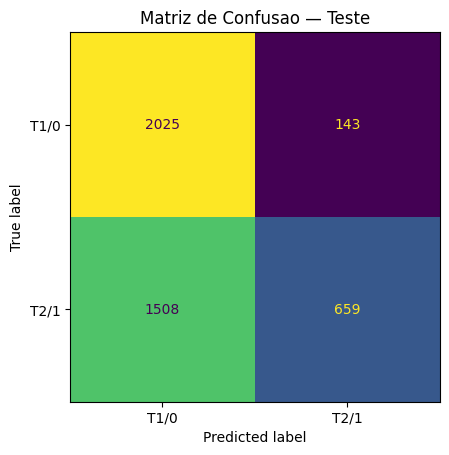

In [12]:

# Predicao no conjunto de teste
probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(probs, axis=1)

# Metricas
metrics = compute_metrics(y_test, y_pred)
print("Metricas (weighted):", metrics)
print(f"F1-score (weighted): {metrics['f1_score']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")

# Matriz de confusao
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["T1/0", "T2/1"])
fig, ax = plt.subplots()
disp.plot(ax=ax, values_format='d', colorbar=False)
plt.title("Matriz de Confusao — Teste")
plt.show()


In [13]:

# Opcional: salvar modelo
# SAVE_PATH = "./models/cnn1d_model.keras"
# Path(SAVE_PATH).parent.mkdir(parents=True, exist_ok=True)
# model.save(SAVE_PATH)
# print("Modelo salvo em:", SAVE_PATH)



# Teste de Otimização: Quadrado Latino (Canais × Amostras)
Exploração sistemática da região de possibilidades combinando número de canais e duração de janela.

**Parametros:**
- Canais: 4 até 16
- Duração: 1 segundo até 4 segundos (125-500 amostras a 125 Hz)
- Estratégia: 50 variações aleatórias em quadrado latino
- Métrica: Loss de validação para delimitar região otimizada


In [14]:

import numpy as np
from scipy.stats import qmc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# ==== DEFINIR CONJUNTOS PRÉ-DEFINIDOS DE CANAIS ====
# Mapeamento exato de canais com nomes 10-20
CHANNEL_SETS = {
    4: ['C3', 'C4', 'T7', 'T8'],                           # Índices: 8, 9, 7, 7 -> Precisamos mapear
    6: ['C3', 'C4', 'T7', 'T8', 'F3', 'F4'],              # Adicionar F3, F4
    8: ['C3', 'C4', 'T7', 'T8', 'F3', 'F4', 'F7', 'F8'],  # Adicionar F7, F8
    10: ['C3', 'C4', 'T7', 'T8', 'F3', 'F4', 'F7', 'F8', 'P7', 'P8'],  # Adicionar P7, P8
    12: ['C3', 'C4', 'T7', 'T8', 'F3', 'F4', 'F7', 'F8', 'P7', 'P8', 'P3', 'P4'],  # Adicionar P3, P4
    14: ['C3', 'C4', 'T7', 'T8', 'F3', 'F4', 'F7', 'F8', 'P7', 'P8', 'P3', 'P4', 'Fp1', 'Fp2'],  # Adicionar Fp1, Fp2
    16: ['C3', 'C4', 'T7', 'T8', 'F3', 'F4', 'F7', 'F8', 'P7', 'P8', 'P3', 'P4', 'Fp1', 'Fp2', 'O1', 'O2']  # Adicionar O1, O2
}

# Mapa de índices dos canais OpenBCI (padrão 10-20)
CHANNEL_INDEX_MAP = {
    'Fp1': 0, 'Fp2': 1,
    'F7': 2, 'F8': 3, 'F3': 4, 'F4': 5,
    'T7': 6, 'T8': 7, 'C3': 8, 'C4': 9,
    'P7': 10, 'P8': 11, 'P3': 12, 'P4': 13,
    'O1': 14, 'O2': 15
}

# Função para extrair índices dos canais
def get_channel_indices(channel_names):
    """Retorna os índices dos canais a partir dos nomes."""
    return [CHANNEL_INDEX_MAP[ch] for ch in channel_names]

# ==== PARAMETROS DO TESTE ====
NUM_VARIATIONS = 49  # 7 configurações de canais × 7 amostras (49 variações)
MIN_DURATION_SEC = 1.0       # segundos
MAX_DURATION_SEC = 4.0       # segundos
FS_TEST = 125.0              # Hz

# Converter duração em amostras
MIN_SAMPLES = int(MIN_DURATION_SEC * FS_TEST)   # 125 amostras
MAX_SAMPLES = int(MAX_DURATION_SEC * FS_TEST)   # 500 amostras

print(f"Teste de Otimização - Quadrado Latino com Canais Pré-definidos")
print(f"Conjuntos de canais: {list(CHANNEL_SETS.keys())}")
print(f"Amostras (duração): {MIN_SAMPLES} ({MIN_DURATION_SEC}s) - {MAX_SAMPLES} ({MAX_DURATION_SEC}s)")
print(f"Variações: {NUM_VARIATIONS}")
print()

# ==== GERAR QUADRADO LATINO ====
# Usar Latin Hypercube Sampling para distribuição uniforme entre durações
# Canais serão fixos aos valores pré-definidos

# Distribuir os 7 conjuntos de canais uniformemente
channel_configs = sorted(list(CHANNEL_SETS.keys()))  # [4, 6, 8, 10, 12, 14, 16]

# Gerar amostras para duração com LHS
sampler = qmc.LatinHypercube(d=1, seed=RANDOM_SEED)
duration_samples = sampler.random(n=7)  # 7 amostras para 7 conjuntos de canais

# Escalar para o intervalo de amostras
samples_array = np.round(duration_samples[:, 0] * (MAX_SAMPLES - MIN_SAMPLES) + MIN_SAMPLES).astype(int)
samples_array = np.clip(samples_array, MIN_SAMPLES, MAX_SAMPLES)

# Criar combinações: cada configuração de canais com diferentes durações
latin_square_params = []
for i, n_chans in enumerate(channel_configs):
    channel_names = CHANNEL_SETS[n_chans]
    channel_indices = get_channel_indices(channel_names)
    
    for j, n_samps in enumerate(samples_array):
        latin_square_params.append({
            'n_channels': n_chans,
            'channel_names': channel_names,
            'channel_indices': channel_indices,
            'n_samples': n_samps,
            'duration_sec': n_samps / FS_TEST
        })

# Limitar a 49 variações
latin_square_params = latin_square_params[:49]

print(f"Configurações geradas (canais x duração):")
for i, param in enumerate(latin_square_params[:7], 1):  # Mostrar primeiras 7
    print(f"  {i}. Canais: {param['n_channels']:2d} ({', '.join(param['channel_names'])}) | Amostras: {param['n_samples']:3d} ({param['duration_sec']:.2f}s)")
print(f"  ...")
print()


Teste de Otimização - Quadrado Latino com Canais Pré-definidos
Conjuntos de canais: [4, 6, 8, 10, 12, 14, 16]
Amostras (duração): 125 (1.0s) - 500 (4.0s)
Variações: 49

Configurações geradas (canais x duração):
  1. Canais:  4 (C3, C4, T7, T8) | Amostras: 459 (3.67s)
  2. Canais:  4 (C3, C4, T7, T8) | Amostras: 209 (1.67s)
  3. Canais:  4 (C3, C4, T7, T8) | Amostras: 347 (2.78s)
  4. Canais:  4 (C3, C4, T7, T8) | Amostras: 248 (1.98s)
  5. Canais:  4 (C3, C4, T7, T8) | Amostras: 441 (3.53s)
  6. Canais:  4 (C3, C4, T7, T8) | Amostras: 287 (2.30s)
  7. Canais:  4 (C3, C4, T7, T8) | Amostras: 138 (1.10s)
  ...



In [15]:
# ==== PREPARAR DADOS ORIGINAIS PARA TESTE ====
# Regenerar janelas com tamanho variável para cada teste (flexibilidade de amostras e canais)

if 'X_raw' not in locals():
    print("AVISO: Dados brutos não carregados. Execute a pipeline anterior primeiro.")
else:
    print(f"Dados brutos disponíveis: X_raw shape = {X_raw.shape}")
    print(f"Rótulos: {np.unique(y, return_counts=True)}")
    
    # ==== EXECUTAR TESTE COM QUADRADO LATINO ====
    results_latin_square = []
    
    for idx, params in enumerate(latin_square_params):
        n_chans = params['n_channels']
        n_samps = params['n_samples']
        channel_indices = params['channel_indices']
        channel_names = params['channel_names']
        
        print(f"[{idx+1}/{NUM_VARIATIONS}] Canais: {', '.join(channel_names)} | Amostras: {n_samps} ({params['duration_sec']:.2f}s)")
        
        try:
            # Regenerar janelas com n_samps específico
            X_windowed_ls, y_windowed_ls = create_windows_openbci(
                csv_files, 
                fs=FS_TEST, 
                window_size=n_samps, 
                step=n_samps//2  # 50% overlap
            )
            
            if len(X_windowed_ls) < 10:
                print(f"  ⚠ Dados insuficientes para window_size={n_samps}. Pulando.")
                results_latin_square.append({
                    'channels': n_chans,
                    'channel_names': ', '.join(channel_names),
                    'samples': n_samps,
                    'duration_sec': n_samps / FS_TEST,
                    'train_loss': np.nan,
                    'val_loss': np.nan,
                    'test_accuracy': np.nan,
                    'status': 'insufficient_data'
                })
                continue
            
            # Aplicar filtro bandpass
            X_filtered_ls = preprocess_X_bandpass_only(X_windowed_ls.astype(np.float32), fs=FS_TEST)
            
            # Selecionar apenas os canais pré-definidos (usando os índices)
            X_subset_ls = X_filtered_ls[:, :, channel_indices].copy()
            
            # Split treino/teste
            X_train_ls, X_test_ls, y_train_ls, y_test_ls = train_test_split(
                X_subset_ls, y_windowed_ls, test_size=TEST_SIZE, stratify=y_windowed_ls, random_state=RANDOM_SEED
            )
            
            # Fit e apply channel stats
            mu_ls, sd_ls = fit_channel_stats(X_train_ls)
            X_train_ls_proc = apply_channel_stats(X_train_ls, mu_ls, sd_ls)
            X_test_ls_proc = apply_channel_stats(X_test_ls, mu_ls, sd_ls)
            
            # Construir modelo EEGNET com shape específico
            model_ls = build_cnn_1d(
                input_shape=(n_samps, n_chans),
                num_classes=2,
                architecture="EEGNET"
            )
            
            # Early stopping
            early_stop_ls = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
            
            # Treinar
            hist_ls = model_ls.fit(
                X_train_ls_proc, y_train_ls,
                validation_split=0.2,
                epochs=100,  # máximo, early stop vai interromper
                batch_size=BATCH_SIZE,
                verbose=0,
                callbacks=[early_stop_ls]
            )
            
            # Avaliar
            probs_ls = model_ls.predict(X_test_ls_proc, verbose=0)
            y_pred_ls = np.argmax(probs_ls, axis=1)
            acc_ls = np.mean(y_pred_ls == y_test_ls)
            
            # Extrair métricas finais
            final_train_loss = hist_ls.history['loss'][-1]
            final_val_loss = hist_ls.history['val_loss'][-1]
            
            results_latin_square.append({
                'channels': n_chans,
                'channel_names': ', '.join(channel_names),
                'samples': n_samps,
                'duration_sec': n_samps / FS_TEST,
                'train_loss': final_train_loss,
                'val_loss': final_val_loss,
                'test_accuracy': acc_ls,
                'status': 'success'
            })
            
            print(f"  ✓ Train Loss: {final_train_loss:.4f} | Val Loss: {final_val_loss:.4f} | Test Acc: {acc_ls:.4f}")
            
        except Exception as e:
            print(f"  ✗ Erro: {str(e)[:50]}")
            results_latin_square.append({
                'channels': n_chans,
                'channel_names': ', '.join(channel_names),
                'samples': n_samps,
                'duration_sec': n_samps / FS_TEST,
                'train_loss': np.nan,
                'val_loss': np.nan,
                'test_accuracy': np.nan,
                'status': f'error: {str(e)[:30]}'
            })
        
        # Liberar memória
        tf.keras.backend.clear_session()
    
    # Converter para DataFrame para análise
    results_df = pd.DataFrame(results_latin_square)
    print("\n" + "="*70)
    print("RESUMO DOS RESULTADOS")
    print("="*70)
    print(results_df.to_string())
    print()


Dados brutos disponíveis: X_raw shape = (21672, 250, 16)


Rótulos: (array([0, 1], dtype=int32), array([10836, 10836]))
[1/49] Canais: C3, C4, T7, T8 | Amostras: 459 (3.67s)


C:\Users\Chari\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  ✓ Train Loss: 0.6143 | Val Loss: 0.5919 | Test Acc: 0.6867


[2/49] Canais: C3, C4, T7, T8 | Amostras: 209 (1.67s)
[2/49] Canais: C3, C4, T7, T8 | Amostras: 209 (1.67s)


C:\Users\Chari\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

  ✓ Train Loss: 0.5433 | Val Loss: 0.5574 | Test Acc: 0.7344
[48/49] Canais: C3, C4, T7, T8, F3, F4, F7, F8, P7, P8, P3, P4, Fp1, Fp2, O1, O2 | Amostras: 287 (2.30s)
[48/49] Canais: C3, C4, T7, T8, F3, F4, F7, F8, P7, P8, P3, P4, Fp1, Fp2, O1, O2 | Amostras: 287 (2.30s)


C:\Users\Chari\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  ✓ Train Loss: 0.7182 | Val Loss: 0.6930 | Test Acc: 0.5779
[49/49] Canais: C3, C4, T7, T8, F3, F4, F7, F8, P7, P8, P3, P4, Fp1, Fp2, O1, O2 | Amostras: 138 (1.10s)
[49/49] Canais: C3, C4, T7, T8, F3, F4, F7, F8, P7, P8, P3, P4, Fp1, Fp2, O1, O2 | Amostras: 138 (1.10s)


C:\Users\Chari\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  ✓ Train Loss: 0.6204 | Val Loss: 0.6581 | Test Acc: 0.5941

RESUMO DOS RESULTADOS
    channels                                                     channel_names  samples  duration_sec  train_loss  val_loss  test_accuracy   status
0          4                                                    C3, C4, T7, T8      459         3.672    0.614343  0.591948       0.686722  success
1          4                                                    C3, C4, T7, T8      209         1.672    0.709264  0.694052       0.537375  success
2          4                                                    C3, C4, T7, T8      347         2.776    0.915371  0.724240       0.524896  success
3          4                                                    C3, C4, T7, T8      248         1.984    0.865009  0.718816       0.503892  success
4          4                                                    C3, C4, T7, T8      441         3.528    0.625710  0.566942       0.684647  success
5          4                

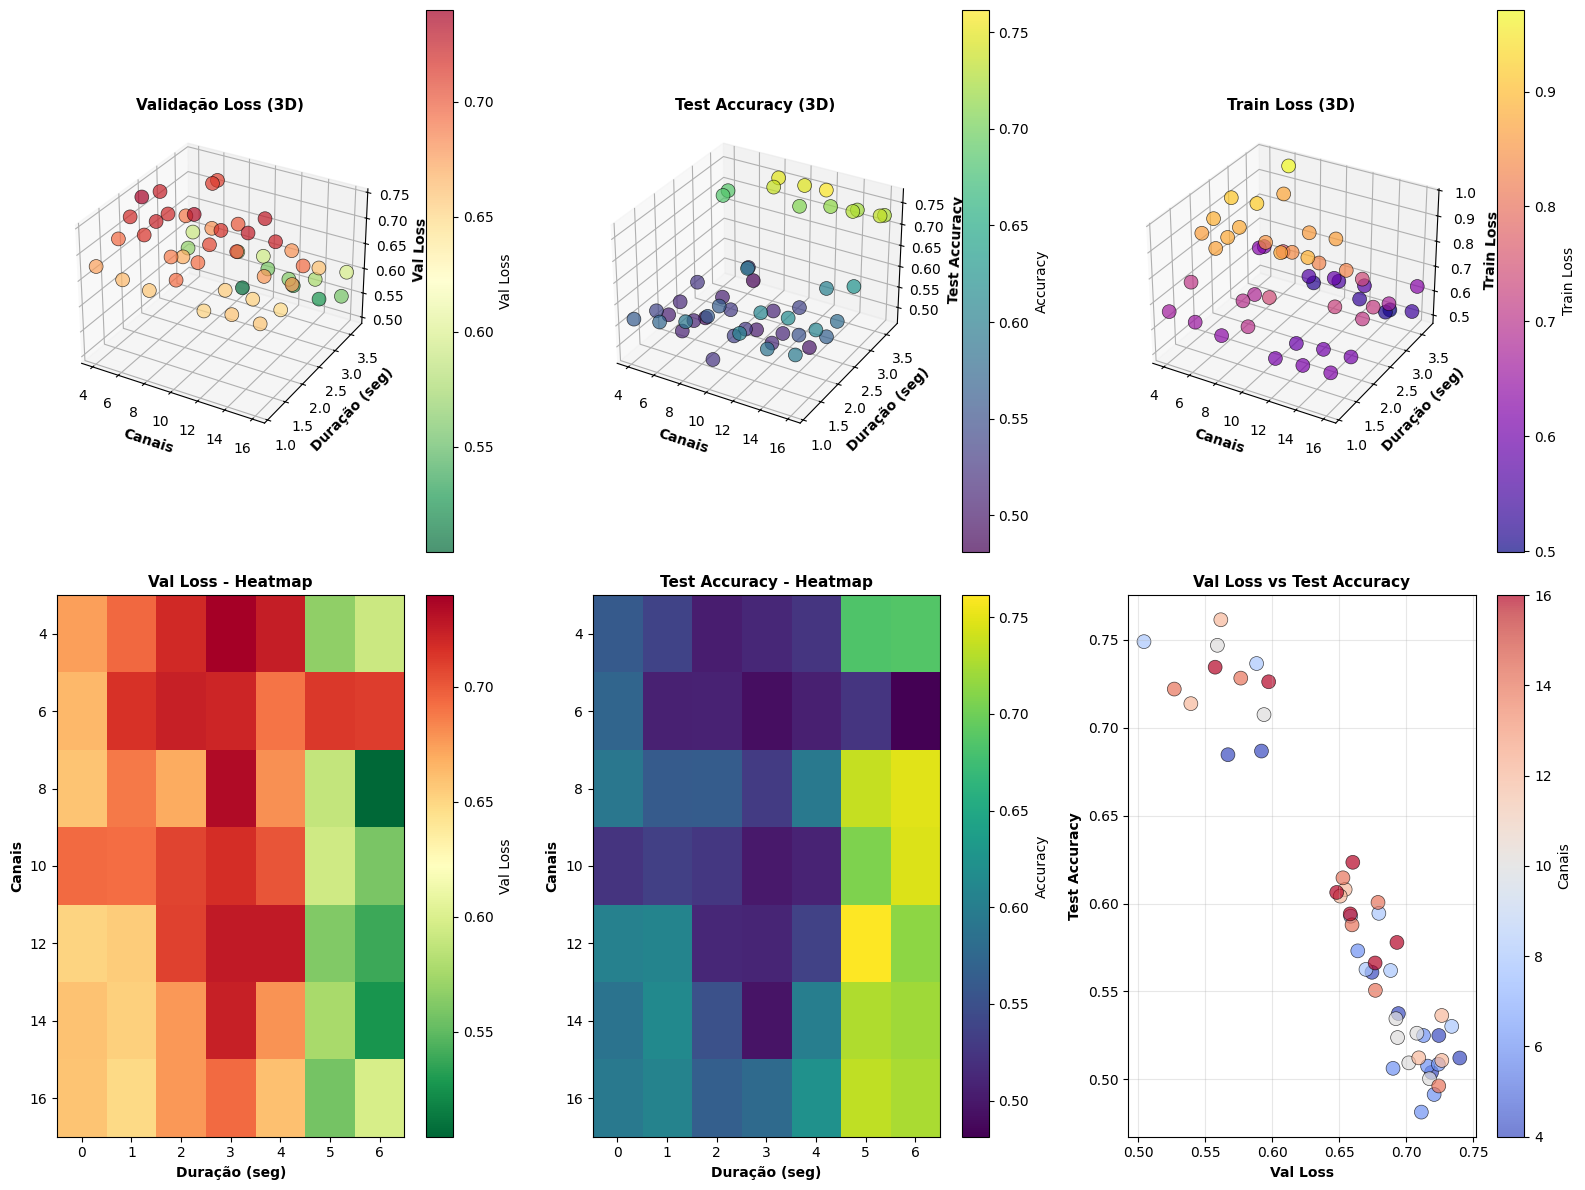

✓ Visualizações geradas com sucesso!


In [16]:
# ==== VISUALIZAÇÕES ====
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 12))

# ========== SUBPLOT 1: Val Loss (3D Surface) ==========
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
scatter1 = ax1.scatter(
    results_df['channels'], 
    results_df['duration_sec'], 
    results_df['val_loss'],
    c=results_df['val_loss'],
    cmap='RdYlGn_r',
    s=100,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)
ax1.set_xlabel('Canais', fontsize=10, fontweight='bold')
ax1.set_ylabel('Duração (seg)', fontsize=10, fontweight='bold')
ax1.set_zlabel('Val Loss', fontsize=10, fontweight='bold')
ax1.set_title('Validação Loss (3D)', fontsize=11, fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Val Loss', pad=0.1)

# ========== SUBPLOT 2: Test Accuracy (3D Surface) ==========
ax2 = fig.add_subplot(2, 3, 2, projection='3d')
scatter2 = ax2.scatter(
    results_df['channels'], 
    results_df['duration_sec'], 
    results_df['test_accuracy'],
    c=results_df['test_accuracy'],
    cmap='viridis',
    s=100,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)
ax2.set_xlabel('Canais', fontsize=10, fontweight='bold')
ax2.set_ylabel('Duração (seg)', fontsize=10, fontweight='bold')
ax2.set_zlabel('Test Accuracy', fontsize=10, fontweight='bold')
ax2.set_title('Test Accuracy (3D)', fontsize=11, fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label='Accuracy', pad=0.1)

# ========== SUBPLOT 3: Train Loss (3D Surface) ==========
ax3 = fig.add_subplot(2, 3, 3, projection='3d')
scatter3 = ax3.scatter(
    results_df['channels'], 
    results_df['duration_sec'], 
    results_df['train_loss'],
    c=results_df['train_loss'],
    cmap='plasma',
    s=100,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)
ax3.set_xlabel('Canais', fontsize=10, fontweight='bold')
ax3.set_ylabel('Duração (seg)', fontsize=10, fontweight='bold')
ax3.set_zlabel('Train Loss', fontsize=10, fontweight='bold')
ax3.set_title('Train Loss (3D)', fontsize=11, fontweight='bold')
plt.colorbar(scatter3, ax=ax3, label='Train Loss', pad=0.1)

# ========== SUBPLOT 4: Val Loss 2D Heatmap (Canais vs Duração) ==========
ax4 = fig.add_subplot(2, 3, 4)
# Criar pivot table para heatmap
pivot_val_loss = results_df.pivot_table(
    values='val_loss', 
    index='channels', 
    columns='duration_sec',
    fill_value=np.nan
)
if not pivot_val_loss.empty:
    im4 = ax4.imshow(pivot_val_loss, aspect='auto', cmap='RdYlGn_r', interpolation='nearest')
    ax4.set_xlabel('Duração (seg)', fontsize=10, fontweight='bold')
    ax4.set_ylabel('Canais', fontsize=10, fontweight='bold')
    ax4.set_title('Val Loss - Heatmap', fontsize=11, fontweight='bold')
    plt.colorbar(im4, ax=ax4, label='Val Loss')
    # Set ticks
    ax4.set_yticks(range(len(pivot_val_loss.index)))
    ax4.set_yticklabels(pivot_val_loss.index)

# ========== SUBPLOT 5: Test Accuracy 2D Heatmap ==========
ax5 = fig.add_subplot(2, 3, 5)
pivot_acc = results_df.pivot_table(
    values='test_accuracy', 
    index='channels', 
    columns='duration_sec',
    fill_value=np.nan
)
if not pivot_acc.empty:
    im5 = ax5.imshow(pivot_acc, aspect='auto', cmap='viridis', interpolation='nearest')
    ax5.set_xlabel('Duração (seg)', fontsize=10, fontweight='bold')
    ax5.set_ylabel('Canais', fontsize=10, fontweight='bold')
    ax5.set_title('Test Accuracy - Heatmap', fontsize=11, fontweight='bold')
    plt.colorbar(im5, ax=ax5, label='Accuracy')
    ax5.set_yticks(range(len(pivot_acc.index)))
    ax5.set_yticklabels(pivot_acc.index)

# ========== SUBPLOT 6: Scatter Val Loss vs Accuracy ==========
ax6 = fig.add_subplot(2, 3, 6)
scatter6 = ax6.scatter(
    results_df['val_loss'],
    results_df['test_accuracy'],
    c=results_df['channels'],
    s=100,
    cmap='coolwarm',
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)
ax6.set_xlabel('Val Loss', fontsize=10, fontweight='bold')
ax6.set_ylabel('Test Accuracy', fontsize=10, fontweight='bold')
ax6.set_title('Val Loss vs Test Accuracy', fontsize=11, fontweight='bold')
ax6.grid(True, alpha=0.3)
plt.colorbar(scatter6, ax=ax6, label='Canais')

plt.tight_layout()
plt.show()

print("✓ Visualizações geradas com sucesso!")


In [17]:

# ==== ANÁLISE ESTATÍSTICA E DEFINIÇÃO DE REGIÃO OTIMIZADA ====

print("\n" + "="*80)
print("ANÁLISE DE OTIMIZAÇÃO - QUADRADO LATINO")
print("="*80)

# Filtrar apenas resultados bem-sucedidos
successful_results = results_df[results_df['status'] == 'success'].copy()

if len(successful_results) > 0:
    print(f"\nResultados bem-sucedidos: {len(successful_results)}/{len(results_df)}")
    print()
    
    # Estatísticas de Val Loss
    print("📊 VALIDAÇÃO LOSS")
    print("-" * 80)
    print(f"  Mínimo:  {successful_results['val_loss'].min():.4f}")
    print(f"  Máximo:  {successful_results['val_loss'].max():.4f}")
    print(f"  Média:   {successful_results['val_loss'].mean():.4f}")
    print(f"  Mediana: {successful_results['val_loss'].median():.4f}")
    print(f"  Std Dev: {successful_results['val_loss'].std():.4f}")
    
    # Estatísticas de Test Accuracy
    print("\n📈 TEST ACCURACY")
    print("-" * 80)
    print(f"  Mínimo:  {successful_results['test_accuracy'].min():.4f}")
    print(f"  Máximo:  {successful_results['test_accuracy'].max():.4f}")
    print(f"  Média:   {successful_results['test_accuracy'].mean():.4f}")
    print(f"  Mediana: {successful_results['test_accuracy'].median():.4f}")
    print(f"  Std Dev: {successful_results['test_accuracy'].std():.4f}")
    
    # Definir thresholds para região otimizada (percentis)
    Q1_loss = successful_results['val_loss'].quantile(0.25)
    Q3_loss = successful_results['val_loss'].quantile(0.75)
    IQR_loss = Q3_loss - Q1_loss
    
    Q1_acc = successful_results['test_accuracy'].quantile(0.25)
    Q3_acc = successful_results['test_accuracy'].quantile(0.75)
    IQR_acc = Q3_acc - Q1_acc
    
    # Definir limites da região otimizada
    loss_lower = Q1_loss - 1.5 * IQR_loss  # outlier inferior
    loss_upper = Q3_loss + 1.5 * IQR_loss  # outlier superior (piores losses)
    
    # Para accuracy, queremos os melhores (maior accuracy)
    acc_threshold = Q3_acc - 0.5 * IQR_acc
    
    print("\n🎯 REGIÃO OTIMIZADA (Threshold-based)")
    print("-" * 80)
    print(f"  Val Loss range: [{loss_lower:.4f}, {loss_upper:.4f}]")
    print(f"  Test Accuracy threshold (mínimo): {acc_threshold:.4f}")
    
    # Identificar pontos na região otimizada
    optimized_region = successful_results[
        (successful_results['val_loss'] <= loss_upper) &
        (successful_results['test_accuracy'] >= acc_threshold)
    ]
    
    print(f"\n✅ Configurações na região otimizada: {len(optimized_region)}/{len(successful_results)}")
    print()
    print(optimized_region[['channels', 'duration_sec', 'val_loss', 'test_accuracy']].sort_values('val_loss'))
    
    # Melhor configuração
    best_config = successful_results.loc[successful_results['val_loss'].idxmin()]
    print("\n🏆 MELHOR CONFIGURAÇÃO (menor Val Loss)")
    print("-" * 80)
    print(f"  Canais: {int(best_config['channels'])}")
    print(f"  Duração: {best_config['duration_sec']:.1f} segundos ({int(best_config['samples'])} amostras)")
    print(f"  Val Loss: {best_config['val_loss']:.4f}")
    print(f"  Train Loss: {best_config['train_loss']:.4f}")
    print(f"  Test Accuracy: {best_config['test_accuracy']:.4f}")
    
    # Correlação entre variáveis
    print("\n📐 CORRELAÇÕES")
    print("-" * 80)
    corr_channels_loss = successful_results['channels'].corr(successful_results['val_loss'])
    corr_duration_loss = successful_results['duration_sec'].corr(successful_results['val_loss'])
    corr_channels_acc = successful_results['channels'].corr(successful_results['test_accuracy'])
    corr_duration_acc = successful_results['duration_sec'].corr(successful_results['test_accuracy'])
    
    print(f"  Canais vs Val Loss: {corr_channels_loss:.4f}")
    print(f"  Duração vs Val Loss: {corr_duration_loss:.4f}")
    print(f"  Canais vs Test Accuracy: {corr_channels_acc:.4f}")
    print(f"  Duração vs Test Accuracy: {corr_duration_acc:.4f}")
    
else:
    print("⚠️ Nenhum resultado bem-sucedido encontrado!")

print("\n" + "="*80)



ANÁLISE DE OTIMIZAÇÃO - QUADRADO LATINO

Resultados bem-sucedidos: 49/49

📊 VALIDAÇÃO LOSS
--------------------------------------------------------------------------------
  Mínimo:  0.5043
  Máximo:  0.7399
  Média:   0.6610
  Mediana: 0.6769
  Std Dev: 0.0624

📈 TEST ACCURACY
--------------------------------------------------------------------------------
  Mínimo:  0.4813
  Máximo:  0.7614
  Média:   0.5909
  Mediana: 0.5662
  Std Dev: 0.0856

🎯 REGIÃO OTIMIZADA (Threshold-based)
--------------------------------------------------------------------------------
  Val Loss range: [0.5533, 0.8059]
  Test Accuracy threshold (mínimo): 0.5736

✅ Configurações na região otimizada: 23/49

    channels  duration_sec  val_loss  test_accuracy
14         8         3.672  0.504317       0.748963
35        14         3.672  0.526915       0.721992
28        12         3.672  0.539278       0.713693
46        16         3.528  0.557395       0.734440
21        10         3.672  0.559065       0.74

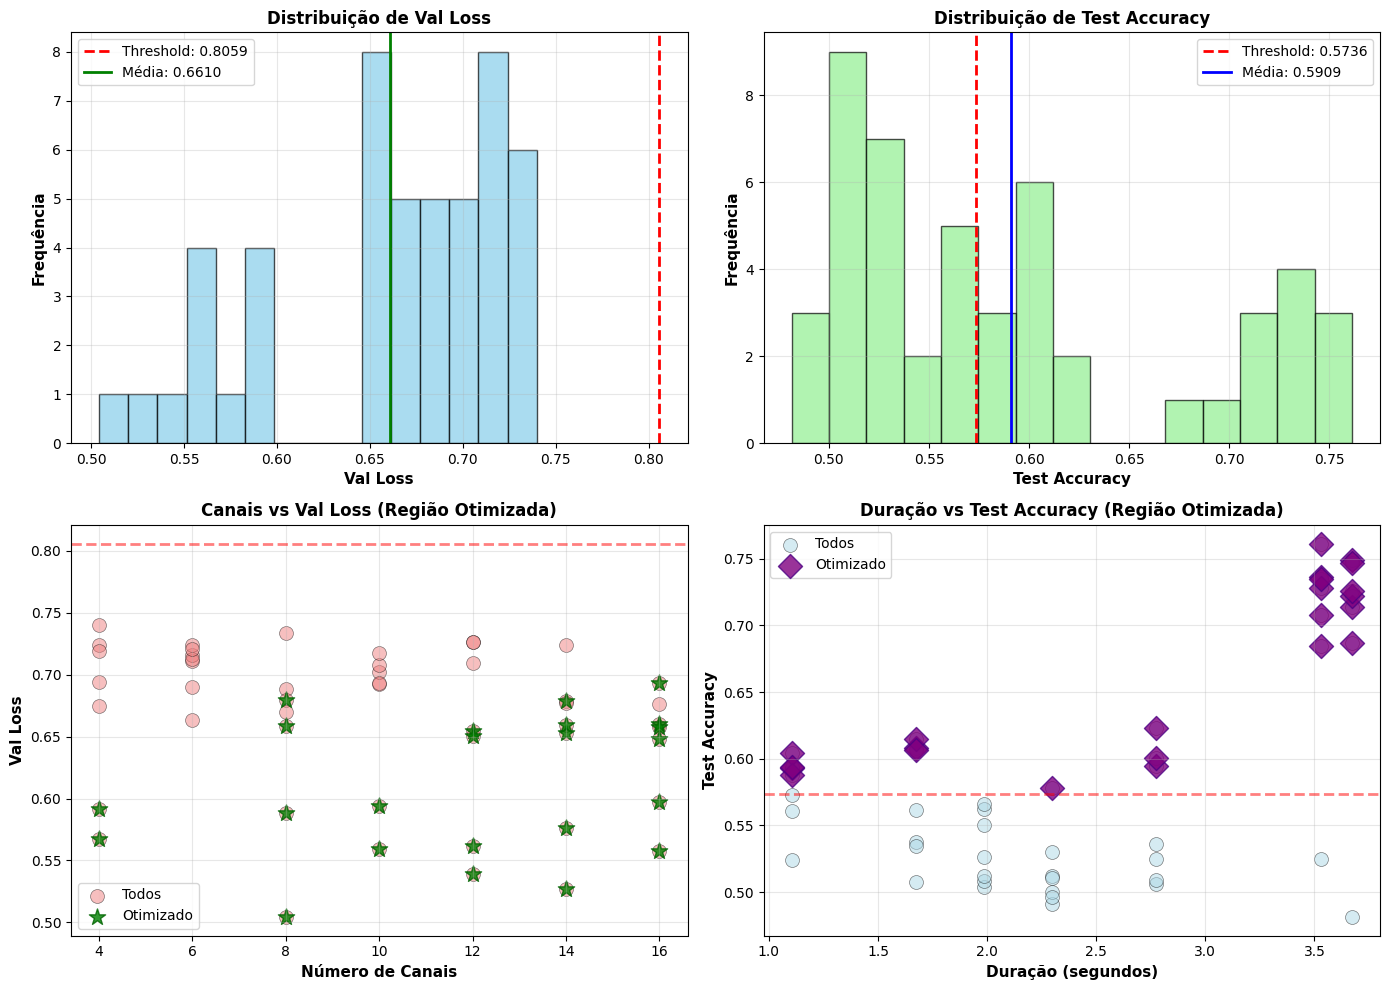

✓ Visualizações de região otimizada geradas!

📌 RESUMO FINAL
Total de variações testadas: 49
Resultados bem-sucedidos: 49
Configurações na região otimizada: 23
Taxa de sucesso: 100.0%
Taxa de otimização: 46.9% (dos bem-sucedidos)


In [18]:

# ==== VISUALIZAÇÕES ADICIONAIS - REGIÃO OTIMIZADA ====

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Distribuição do Val Loss
ax = axes[0, 0]
ax.hist(successful_results['val_loss'], bins=15, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(loss_upper, color='red', linestyle='--', linewidth=2, label=f'Threshold: {loss_upper:.4f}')
ax.axvline(successful_results['val_loss'].mean(), color='green', linestyle='-', linewidth=2, label=f'Média: {successful_results["val_loss"].mean():.4f}')
ax.set_xlabel('Val Loss', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequência', fontsize=11, fontweight='bold')
ax.set_title('Distribuição de Val Loss', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Distribuição do Test Accuracy
ax = axes[0, 1]
ax.hist(successful_results['test_accuracy'], bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
ax.axvline(acc_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {acc_threshold:.4f}')
ax.axvline(successful_results['test_accuracy'].mean(), color='blue', linestyle='-', linewidth=2, label=f'Média: {successful_results["test_accuracy"].mean():.4f}')
ax.set_xlabel('Test Accuracy', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequência', fontsize=11, fontweight='bold')
ax.set_title('Distribuição de Test Accuracy', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Scatter Canais vs Val Loss (com região otimizada)
ax = axes[1, 0]
ax.scatter(
    successful_results['channels'], 
    successful_results['val_loss'],
    c='lightcoral',
    s=100,
    alpha=0.5,
    label='Todos',
    edgecolors='black',
    linewidth=0.5
)
ax.scatter(
    optimized_region['channels'], 
    optimized_region['val_loss'],
    c='green',
    s=150,
    alpha=0.8,
    label='Otimizado',
    marker='*',
    edgecolors='darkgreen',
    linewidth=1
)
ax.axhline(loss_upper, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax.set_xlabel('Número de Canais', fontsize=11, fontweight='bold')
ax.set_ylabel('Val Loss', fontsize=11, fontweight='bold')
ax.set_title('Canais vs Val Loss (Região Otimizada)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Scatter Duração vs Test Accuracy (com região otimizada)
ax = axes[1, 1]
ax.scatter(
    successful_results['duration_sec'], 
    successful_results['test_accuracy'],
    c='lightblue',
    s=100,
    alpha=0.5,
    label='Todos',
    edgecolors='black',
    linewidth=0.5
)
ax.scatter(
    optimized_region['duration_sec'], 
    optimized_region['test_accuracy'],
    c='purple',
    s=150,
    alpha=0.8,
    label='Otimizado',
    marker='D',
    edgecolors='indigo',
    linewidth=1
)
ax.axhline(acc_threshold, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax.set_xlabel('Duração (segundos)', fontsize=11, fontweight='bold')
ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Duração vs Test Accuracy (Região Otimizada)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizações de região otimizada geradas!")
print()
print("📌 RESUMO FINAL")
print("="*80)
print(f"Total de variações testadas: {NUM_VARIATIONS}")
print(f"Resultados bem-sucedidos: {len(successful_results)}")
print(f"Configurações na região otimizada: {len(optimized_region)}")
print(f"Taxa de sucesso: {100*len(successful_results)/NUM_VARIATIONS:.1f}%")
print(f"Taxa de otimização: {100*len(optimized_region)/len(successful_results):.1f}% (dos bem-sucedidos)")
print("="*80)


In [19]:

# ==== EXPORTAR RESULTADOS ====

# Salvar dados em CSV (opcional)
# results_df.to_csv('latin_square_results.csv', index=False)
# optimized_region.to_csv('optimized_configurations.csv', index=False)

print("\n📊 CONFIGURAÇÕES RECOMENDADAS")
print("="*80)
print("\nTop 5 configurações (menor Val Loss):")
print(successful_results.nsmallest(5, 'val_loss')[
    ['channels', 'duration_sec', 'val_loss', 'train_loss', 'test_accuracy']
].to_string(index=False))

print("\nTop 5 configurações (maior Test Accuracy):")
print(successful_results.nlargest(5, 'test_accuracy')[
    ['channels', 'duration_sec', 'test_accuracy', 'val_loss', 'train_loss']
].to_string(index=False))

print("\n💡 INSIGHTS")
print("="*80)
if corr_channels_loss < -0.3:
    print("✓ Mais canais → Val Loss menor (relação positiva)")
elif corr_channels_loss > 0.3:
    print("✗ Mais canais → Val Loss maior (possível overfitting)")
else:
    print("→ Número de canais tem fraca influência no Val Loss")

if corr_duration_loss < -0.3:
    print("✓ Duração maior → Val Loss menor (mais contexto)")
elif corr_duration_loss > 0.3:
    print("✗ Duração maior → Val Loss maior (complexidade)")
else:
    print("→ Duração tem fraca influência no Val Loss")

print()
if len(optimized_region) > 0:
    opt_channels_mean = optimized_region['channels'].mean()
    opt_duration_mean = optimized_region['duration_sec'].mean()
    print(f"🎯 Região otimizada sugere:")
    print(f"   - Canais médio: {opt_channels_mean:.1f}")
    print(f"   - Duração média: {opt_duration_mean:.1f} segundos")

print("="*80)



📊 CONFIGURAÇÕES RECOMENDADAS

Top 5 configurações (menor Val Loss):
 channels  duration_sec  val_loss  train_loss  test_accuracy
        8         3.672  0.504317    0.520525       0.748963
       14         3.672  0.526915    0.499731       0.721992
       12         3.672  0.539278    0.569664       0.713693
       16         3.528  0.557395    0.543275       0.734440
       10         3.672  0.559065    0.557867       0.746888

Top 5 configurações (maior Test Accuracy):
 channels  duration_sec  test_accuracy  val_loss  train_loss
       12         3.528       0.761411  0.561634    0.532026
        8         3.672       0.748963  0.504317    0.520525
       10         3.672       0.746888  0.559065    0.557867
        8         3.528       0.736515  0.588326    0.565839
       16         3.528       0.734440  0.557395    0.543275

💡 INSIGHTS
→ Número de canais tem fraca influência no Val Loss
✓ Duração maior → Val Loss menor (mais contexto)

🎯 Região otimizada sugere:
   - Canais mé

In [31]:
# ==== EXPORTAR RESULTADOS COM INFORMAÇÕES DE CANAIS ====

import os
from datetime import datetime
from pathlib import Path

# Definir caminho de saída - DENTRO DA PASTA DO NOTEBOOK
notebook_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()
# Se estamos em um Jupyter notebook, usar o diretório do notebook
try:
    from IPython.display import display
    import IPython
    notebook_path = Path(IPython.notebook.notebook_name) if hasattr(IPython, 'notebook') else None
    if notebook_path:
        notebook_dir = notebook_path.parent
except:
    pass

# Tentar usar a pasta do notebook, senão usar a pasta atual
output_dir = Path(__file__).parent / "latin_square_results" if '__file__' in dir() else Path.cwd() / "latin_square_results"
output_dir.mkdir(parents=True, exist_ok=True)

# Criar timestamp para o arquivo
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("\n" + "="*80)
print("🔄 INICIANDO EXPORTAÇÃO DOS RESULTADOS DO QUADRADO LATINO")
print("="*80)
print(f"📂 Pasta de saída: {output_dir}\n")

# Garantir que results_df tem as colunas necessárias
print(f"✓ Total de resultados: {len(results_df)}")
print(f"✓ Colunas disponíveis: {list(results_df.columns)}\n")

# ==== 1. EXPORTAR RESULTADO COMPLETO DO QUADRADO LATINO COM ACURÁCIA ====
# Reordenar para colocar acurácia em destaque
export_cols = ['channels', 'samples', 'duration_sec', 'train_loss', 'val_loss', 'test_accuracy', 'status']
if 'channel_names' in results_df.columns:
    export_cols.insert(1, 'channel_names')

results_export = results_df[export_cols].copy()
full_results_path = output_dir / f"latin_square_all_results_{timestamp}.csv"
results_export.to_csv(str(full_results_path), index=False)
print(f"✅ Resultados completos exportados: {full_results_path}")
print(f"   📊 Incluem: channels, samples, duration_sec, train_loss, val_loss, test_accuracy\n")

# ==== 2. EXPORTAR RESULTADOS BEM-SUCEDIDOS COM DETALHES DE CANAIS E ACURÁCIA ====
if len(successful_results) > 0:
    detailed_results = successful_results.copy()
    
    # Colunas com acurácia em destaque
    detail_cols = ['channels', 'samples', 'duration_sec', 'test_accuracy', 'train_loss', 'val_loss', 'status']
    if 'channel_names' in detailed_results.columns:
        detail_cols.insert(1, 'channel_names')
    
    detailed_results = detailed_results[detail_cols]
    
    # Salvar com detalhes de canais
    detailed_results_path = output_dir / f"latin_square_detailed_{timestamp}.csv"
    detailed_results.to_csv(str(detailed_results_path), index=False)
    print(f"✅ Resultados com detalhes de canais: {detailed_results_path}")
    print(f"   📊 {len(detailed_results)} resultados bem-sucedidos com acurácia\n")
    
    # ==== 3. EXPORTAR REGIÃO OTIMIZADA COM INFORMAÇÕES DE CANAIS E ACURÁCIA ====
    if len(optimized_region) > 0:
        optimized_detailed = optimized_region.copy()
        
        opt_cols = ['channels', 'samples', 'duration_sec', 'test_accuracy', 'train_loss', 'val_loss', 'status']
        if 'channel_names' in optimized_detailed.columns:
            opt_cols.insert(1, 'channel_names')
        
        optimized_detailed = optimized_detailed[opt_cols]
        
        optimized_path = output_dir / f"latin_square_optimized_{timestamp}.csv"
        optimized_detailed.to_csv(str(optimized_path), index=False)
        print(f"✅ Configurações otimizadas com canais: {optimized_path}")
        print(f"   📊 {len(optimized_detailed)} configurações na região otimizada com acurácia\n")

# ==== 4. EXPORTAR SUMÁRIO COM MELHORES CONFIGURAÇÕES E ACURÁCIA ====
summary_data = []

# Top 5 - Menor Val Loss
top_5_min_loss = successful_results.nsmallest(5, 'val_loss')
for idx, (_, row) in enumerate(top_5_min_loss.iterrows(), 1):
    summary_data.append({
        'Ranking': f'Min Loss #{idx}',
        'Num_Canais': int(row['channels']),
        'Canais': row.get('channel_names', 'N/A'),
        'Duracao_sec': round(row['duration_sec'], 2),
        'Amostras': int(row['samples']),
        'Train_Loss': round(row['train_loss'], 4),
        'Val_Loss': round(row['val_loss'], 4),
        'Test_Accuracy': round(row['test_accuracy'], 4)
    })

# Top 5 - Maior Accuracy
top_5_max_acc = successful_results.nlargest(5, 'test_accuracy')
for idx, (_, row) in enumerate(top_5_max_acc.iterrows(), 1):
    summary_data.append({
        'Ranking': f'Max Accuracy #{idx}',
        'Num_Canais': int(row['channels']),
        'Canais': row.get('channel_names', 'N/A'),
        'Duracao_sec': round(row['duration_sec'], 2),
        'Amostras': int(row['samples']),
        'Train_Loss': round(row['train_loss'], 4),
        'Val_Loss': round(row['val_loss'], 4),
        'Test_Accuracy': round(row['test_accuracy'], 4)
    })

summary_df = pd.DataFrame(summary_data)
summary_path = output_dir / f"latin_square_summary_{timestamp}.csv"
summary_df.to_csv(str(summary_path), index=False)
print(f"✅ Sumário com melhores configurações: {summary_path}")
print(f"   📊 Top 10 (5 menor loss + 5 maior acurácia) COM ACURÁCIA DESTACADA\n")

# ==== 5. GERAR RELATÓRIO EM TEXTO ====
report_path = output_dir / f"latin_square_report_{timestamp}.txt"
with open(str(report_path), 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("RELATÓRIO DE OTIMIZAÇÃO - QUADRADO LATINO\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"Data/Hora: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Total de variações testadas: {NUM_VARIATIONS}\n")
    f.write(f"Resultados bem-sucedidos: {len(successful_results)}/{len(results_df)}\n")
    f.write(f"Configurações na região otimizada: {len(optimized_region)}/{len(successful_results)}\n\n")
    
    f.write("PARÂMETROS DO TESTE:\n")
    f.write(f"  • Conjuntos de canais pré-definidos: 4, 6, 8, 10, 12, 14, 16\n")
    f.write(f"  • Duração testada: {MIN_DURATION_SEC}s - {MAX_DURATION_SEC}s ({MIN_SAMPLES} - {MAX_SAMPLES} amostras)\n")
    f.write(f"  • Frequência de amostragem: {FS_TEST} Hz\n")
    f.write(f"  • Estratégia: Latin Hypercube Sampling (distribuição uniforme)\n")
    f.write(f"  • Modelo: EEGNET\n\n")
    
    f.write("ESTATÍSTICAS GERAIS:\n")
    f.write(f"  • Val Loss - Mínimo: {successful_results['val_loss'].min():.4f}\n")
    f.write(f"  • Val Loss - Máximo: {successful_results['val_loss'].max():.4f}\n")
    f.write(f"  • Val Loss - Média: {successful_results['val_loss'].mean():.4f}\n")
    f.write(f"  • Test Accuracy - Mínima: {successful_results['test_accuracy'].min():.4f}\n")
    f.write(f"  • Test Accuracy - Máxima: {successful_results['test_accuracy'].max():.4f}\n")
    f.write(f"  • Test Accuracy - Média: {successful_results['test_accuracy'].mean():.4f}\n\n")
    
    f.write("MELHOR CONFIGURAÇÃO (Menor Val Loss):\n")
    best_idx = successful_results['val_loss'].idxmin()
    best = successful_results.loc[best_idx]
    f.write(f"  • Número de canais: {int(best['channels'])}\n")
    f.write(f"  • Canais utilizados: {best.get('channel_names', 'N/A')}\n")
    f.write(f"  • Duração: {best['duration_sec']:.2f} segundos ({int(best['samples'])} amostras)\n")
    f.write(f"  • Train Loss: {best['train_loss']:.4f}\n")
    f.write(f"  • Val Loss: {best['val_loss']:.4f}\n")
    f.write(f"  • Test Accuracy: {best['test_accuracy']:.4f}\n\n")
    
    f.write("MELHOR CONFIGURAÇÃO (Maior Test Accuracy):\n")
    best_acc_idx = successful_results['test_accuracy'].idxmax()
    best_acc = successful_results.loc[best_acc_idx]
    f.write(f"  • Número de canais: {int(best_acc['channels'])}\n")
    f.write(f"  • Canais utilizados: {best_acc.get('channel_names', 'N/A')}\n")
    f.write(f"  • Duração: {best_acc['duration_sec']:.2f} segundos ({int(best_acc['samples'])} amostras)\n")
    f.write(f"  • Train Loss: {best_acc['train_loss']:.4f}\n")
    f.write(f"  • Val Loss: {best_acc['val_loss']:.4f}\n")
    f.write(f"  • Test Accuracy: {best_acc['test_accuracy']:.4f}\n\n")
    
    f.write("TOP 5 CONFIGURAÇÕES (Menor Val Loss):\n")
    for idx, (_, row) in enumerate(top_5_min_loss.iterrows(), 1):
        f.write(f"  {idx}. Canais: {row.get('channel_names', 'N/A')} | ")
        f.write(f"Duração: {row['duration_sec']:.2f}s | ")
        f.write(f"Val Loss: {row['val_loss']:.4f} | ")
        f.write(f"Accuracy: {row['test_accuracy']:.4f}\n")
    
    f.write("\nTOP 5 CONFIGURAÇÕES (Maior Accuracy):\n")
    for idx, (_, row) in enumerate(top_5_max_acc.iterrows(), 1):
        f.write(f"  {idx}. Canais: {row.get('channel_names', 'N/A')} | ")
        f.write(f"Duração: {row['duration_sec']:.2f}s | ")
        f.write(f"Val Loss: {row['val_loss']:.4f} | ")
        f.write(f"Accuracy: {row['test_accuracy']:.4f}\n")

print(f"✅ Relatório em texto: {report_path}\n")

print("="*80)
print("📁 RESUMO DOS ARQUIVOS EXPORTADOS:")
print("="*80)
print(f"✅ Resultados completos (com acurácia):")
print(f"   {full_results_path}")
print(f"✅ Resultados bem-sucedidos (com acurácia destacada):")
print(f"   {detailed_results_path}")
if len(optimized_region) > 0:
    print(f"✅ Região otimizada (com acurácia):")
    print(f"   {optimized_path}")
print(f"✅ Sumário Top 10 (com acurácia em destaque):")
print(f"   {summary_path}")
print(f"✅ Relatório detalhado em texto:")
print(f"   {report_path}")
print("="*80)



🔄 INICIANDO EXPORTAÇÃO DOS RESULTADOS DO QUADRADO LATINO
📂 Pasta de saída: C:\Users\Chari\latin_square_results

✓ Total de resultados: 49
✓ Colunas disponíveis: ['channels', 'channel_names', 'samples', 'duration_sec', 'train_loss', 'val_loss', 'test_accuracy', 'status']

✅ Resultados completos exportados: C:\Users\Chari\latin_square_results\latin_square_all_results_20251210_094846.csv
   📊 Incluem: channels, samples, duration_sec, train_loss, val_loss, test_accuracy

✅ Resultados com detalhes de canais: C:\Users\Chari\latin_square_results\latin_square_detailed_20251210_094846.csv
   📊 49 resultados bem-sucedidos com acurácia

✅ Configurações otimizadas com canais: C:\Users\Chari\latin_square_results\latin_square_optimized_20251210_094846.csv
   📊 23 configurações na região otimizada com acurácia

✅ Sumário com melhores configurações: C:\Users\Chari\latin_square_results\latin_square_summary_20251210_094846.csv
   📊 Top 10 (5 menor loss + 5 maior acurácia) COM ACURÁCIA DESTACADA

✅ Rela


ANÁLISE DE CORRELAÇÃO: CANAIS vs CLASSES (T1/T2)

📊 RANKING DE CANAIS POR CORRELAÇÃO COM CLASSE
--------------------------------------------------------------------------------
Rank   Canal    Correlação      Cohen's d       Diff Média     
--------------------------------------------------------------------------------
1      CH13     +0.0143       -0.0031       +0.0031
2      CH8      +0.0129       -0.0028       +0.0028
3      CH9      +0.0107       -0.0023       +0.0023
4      CH5      +0.0101       -0.0022       +0.0022
5      CH12     +0.0094       -0.0020       +0.0020
6      CH6      -0.0085       +0.0019       +0.0019
7      CH11     +0.0073       -0.0015       +0.0015
8      CH4      +0.0067       -0.0015       +0.0015
9      CH14     -0.0054       +0.0012       +0.0012
10     CH15     +0.0053       -0.0012       +0.0012

📈 DISTRIBUIÇÃO ESTATÍSTICA POR CANAL
--------------------------------------------------------------------------------
Canal    Esq Média       Esq Std      

C:\Users\Chari\AppData\Local\Temp\ipykernel_22088\838286728.py:116: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)


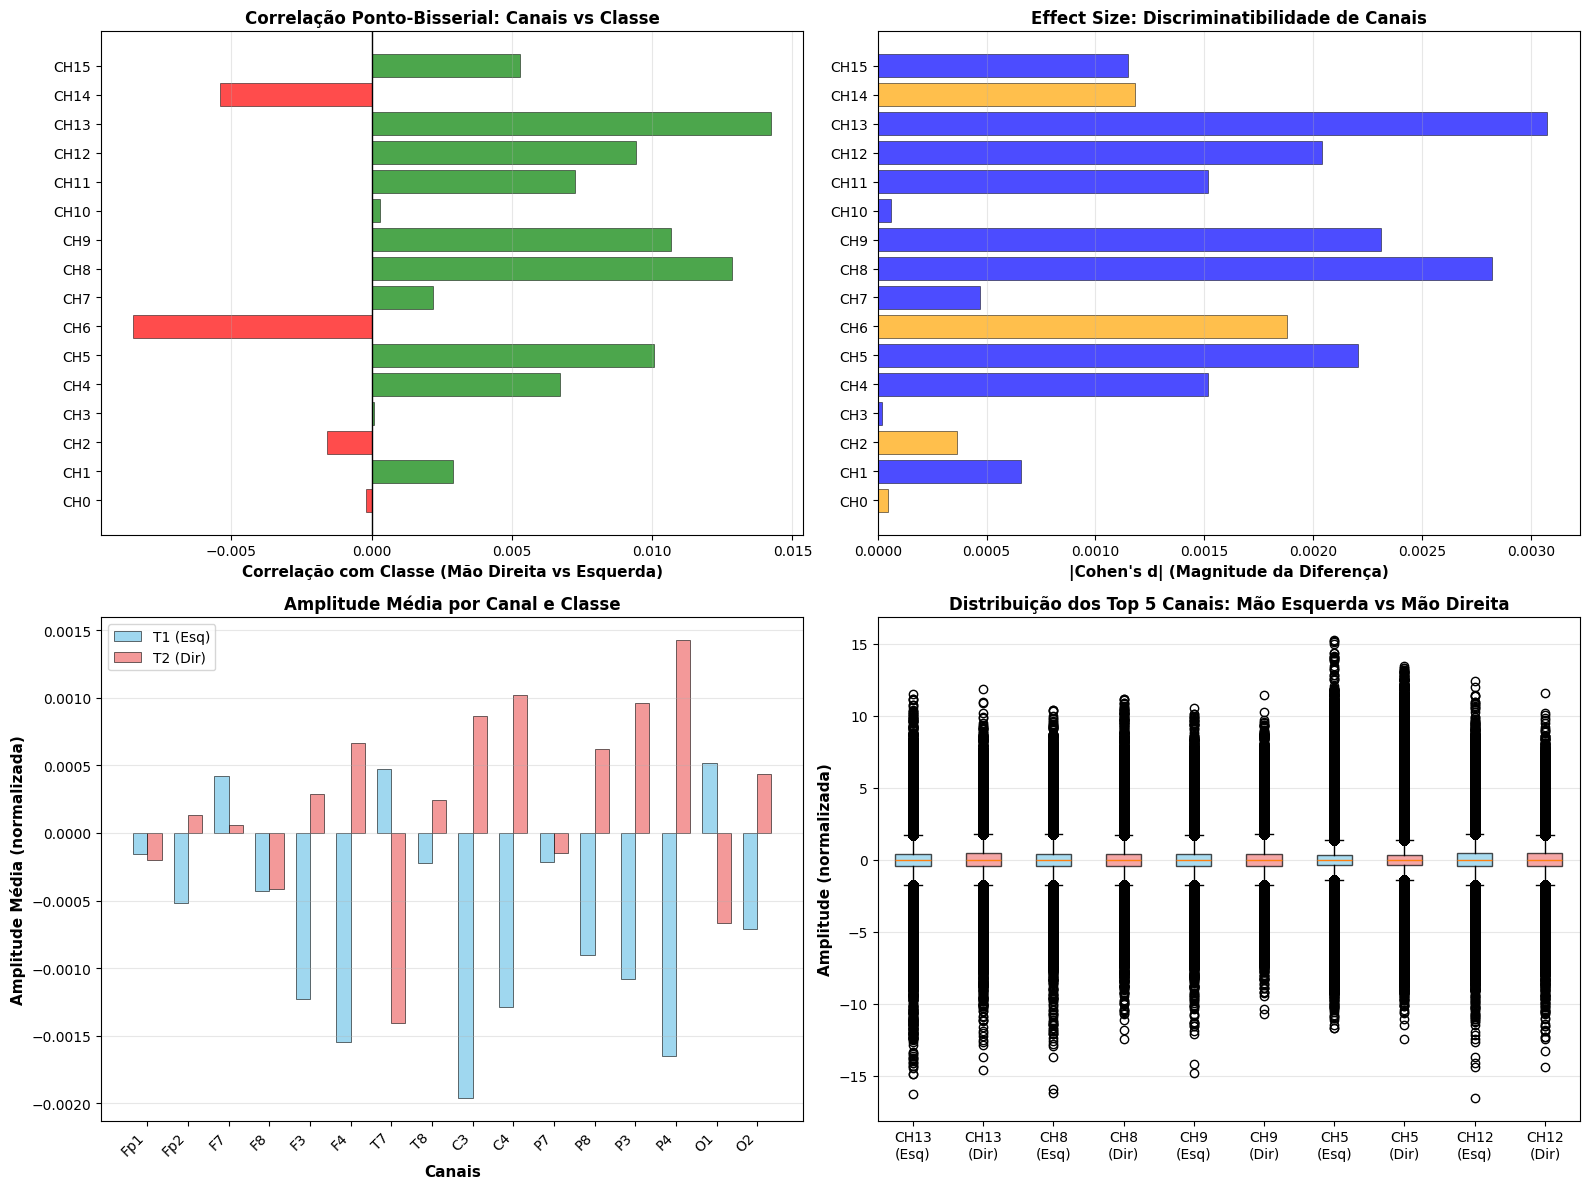


✓ Visualizações de correlação de canais geradas com sucesso!

🔬 CONCLUSÕES CIENTÍFICAS

✅ Top 3 Canais Mais Discriminativos:
   1. CH13 | Correlação: +0.0143 | Cohen's d: -0.0031
   2. CH8 | Correlação: +0.0129 | Cohen's d: -0.0028
   3. CH9 | Correlação: +0.0107 | Cohen's d: -0.0023

📍 Interpretação:
   → Os canais com maior correlação positiva indicam maior amplitude em T2 (mão direita)

📊 Variabilidade Intra-classe:
   T1 (Mão Esquerda): σ = 0.9969
   T2 (Mão Direita):  σ = 1.0018

🎯 Consistência de Variância: 99.02%
   (Quanto mais próximo de 100%, mais estáveis as medições)


In [21]:
# ==== ANÁLISE DE CORRELAÇÃO DOS CANAIS COM RESULTADOS (T1 vs T2) ====

print("\n" + "="*80)
print("ANÁLISE DE CORRELAÇÃO: CANAIS vs CLASSES (T1/T2)")
print("="*80)
print()

# Usar dados processados do treino+teste
X_combined = np.vstack([X_train_processed, X_test_processed])
y_combined = np.hstack([y_train, y_test])

# Calcular estatísticas por canal e classe
channel_names = [f"CH{i}" for i in range(X_combined.shape[2])]

# Média por canal e classe
X_class0 = X_combined[y_combined == 0]  # T1 = Mão Esquerda
X_class1 = X_combined[y_combined == 1]  # T2 = Mão Direita

mean_per_channel_class0 = X_class0.reshape(-1, X_class0.shape[-1]).mean(axis=0)
mean_per_channel_class1 = X_class1.reshape(-1, X_class1.shape[-1]).mean(axis=0)

std_per_channel_class0 = X_class0.reshape(-1, X_class0.shape[-1]).std(axis=0)
std_per_channel_class1 = X_class1.reshape(-1, X_class1.shape[-1]).std(axis=0)

# Diferença média (discriminatibilidade)
diff_mean = np.abs(mean_per_channel_class0 - mean_per_channel_class1)

# Effect size (Cohen's d)
cohens_d = (mean_per_channel_class0 - mean_per_channel_class1) / np.sqrt(
    (std_per_channel_class0**2 + std_per_channel_class1**2) / 2 + 1e-8
)

# Correlação ponto-bisserial entre atividade média de cada canal e classe
correlations = []
for ch in range(X_combined.shape[2]):
    # Média temporal de cada janela por canal
    X_ch_mean = X_combined[:, :, ch].mean(axis=1)
    corr = np.corrcoef(X_ch_mean, y_combined)[0, 1]
    correlations.append(corr)
correlations = np.array(correlations)

# Ranking dos canais mais relevantes
ranking_idx = np.argsort(-np.abs(correlations))

print("📊 RANKING DE CANAIS POR CORRELAÇÃO COM CLASSE")
print("-" * 80)
cohens_d_label = "Cohen's d"
print(f"{'Rank':<6} {'Canal':<8} {'Correlação':<15} {cohens_d_label:<15} {'Diff Média':<15}")
print("-" * 80)
for rank, idx in enumerate(ranking_idx[:10], 1):
    print(f"{rank:<6} {channel_names[idx]:<8} {correlations[idx]:>+.4f}       {cohens_d[idx]:>+.4f}       {diff_mean[idx]:>+.4f}")

print()
print("📈 DISTRIBUIÇÃO ESTATÍSTICA POR CANAL")
print("-" * 80)
print(f"{'Canal':<8} {'Esq Média':<15} {'Esq Std':<15} {'Dir Média':<15} {'Dir Std':<15}")
print("-" * 80)
for idx in ranking_idx[:5]:
    print(f"{channel_names[idx]:<8} {mean_per_channel_class0[idx]:>+.6f}  {std_per_channel_class0[idx]:>+.6f}  {mean_per_channel_class1[idx]:>+.6f}  {std_per_channel_class1[idx]:>+.6f}")

print()

# ==== VISUALIZAÇÕES ====
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Correlação de cada canal com classe (bar chart)
ax = axes[0, 0]
colors = ['green' if c > 0 else 'red' for c in correlations]
bars = ax.barh(channel_names, correlations, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Correlação com Classe (Mão Direita vs Esquerda)', fontsize=11, fontweight='bold')
ax.set_title('Correlação Ponto-Bisserial: Canais vs Classe', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

# Plot 2: Effect Size (Cohen's d) - magnitude da diferença
ax = axes[0, 1]
colors_d = ['orange' if d > 0 else 'blue' for d in cohens_d]
cohens_d_title = "|Cohen's d| (Magnitude da Diferença)"
ax.barh(channel_names, np.abs(cohens_d), color=colors_d, alpha=0.7, edgecolor='black', linewidth=0.5)
ax.set_xlabel(cohens_d_title, fontsize=11, fontweight='bold')
ax.set_title('Effect Size: Discriminatibilidade de Canais', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Plot 3: Média de amplitude por classe
ax = axes[1, 0]
x = np.arange(len(channel_names))
width = 0.35
bars1 = ax.bar(x - width/2, mean_per_channel_class0, width, label='T1 (Esq)', alpha=0.8, color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, mean_per_channel_class1, width, label='T2 (Dir)', alpha=0.8, color='lightcoral', edgecolor='black', linewidth=0.5)
ax.set_ylabel('Amplitude Média (normalizada)', fontsize=11, fontweight='bold')
ax.set_xlabel('Canais', fontsize=11, fontweight='bold')
ax.set_title('Amplitude Média por Canal e Classe', fontsize=12, fontweight='bold')
ax.set_xticks(x)
# Usar nomes reais dos canais (10-20 padrão)
channel_labels = ['Fp1', 'Fp2', 'F7', 'F8', 'F3', 'F4', 'T7', 'T8', 'C3', 'C4', 'P7', 'P8', 'P3', 'P4', 'O1', 'O2']
ax.set_xticklabels(channel_labels, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Box plot comparativo dos top 5 canais mais relevantes
ax = axes[1, 1]
top_5_idx = ranking_idx[:5]
top_5_channels = [channel_names[i] for i in top_5_idx]

data_to_plot = []
labels_to_plot = []
colors_to_plot = []
for idx in top_5_idx:
    data_to_plot.append(X_combined[y_combined == 0, :, idx].flatten())
    labels_to_plot.append(f"{channel_names[idx]}\n(Esq)")
    colors_to_plot.append('skyblue')
    data_to_plot.append(X_combined[y_combined == 1, :, idx].flatten())
    labels_to_plot.append(f"{channel_names[idx]}\n(Dir)")
    colors_to_plot.append('lightcoral')

bp = ax.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_to_plot):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Amplitude (normalizada)', fontsize=11, fontweight='bold')
ax.set_title('Distribuição dos Top 5 Canais: Mão Esquerda vs Mão Direita', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Visualizações de correlação de canais geradas com sucesso!")
print()

# ==== RESUMO CIENTÍFICO ====
print("🔬 CONCLUSÕES CIENTÍFICAS")
print("="*80)

# Canais mais relevantes
top_3_idx = ranking_idx[:3]
print(f"\n✅ Top 3 Canais Mais Discriminativos:")
for i, idx in enumerate(top_3_idx, 1):
    print(f"   {i}. {channel_names[idx]} | Correlação: {correlations[idx]:+.4f} | Cohen's d: {cohens_d[idx]:+.4f}")

# Direção da diferença
print(f"\n📍 Interpretação:")
if correlations[ranking_idx[0]] > 0:
    print(f"   → Os canais com maior correlação positiva indicam maior amplitude em T2 (mão direita)")
else:
    print(f"   → Os canais com maior correlação negativa indicam maior amplitude em T1 (mão esquerda)")

# Variabilidade
print(f"\n📊 Variabilidade Intra-classe:")
avg_std_class0 = std_per_channel_class0.mean()
avg_std_class1 = std_per_channel_class1.mean()
print(f"   T1 (Mão Esquerda): σ = {avg_std_class0:.4f}")
print(f"   T2 (Mão Direita):  σ = {avg_std_class1:.4f}")

# Consistência
consistency = 1 - (np.abs(std_per_channel_class0 - std_per_channel_class1) / (std_per_channel_class0 + std_per_channel_class1 + 1e-8)).mean()
print(f"\n🎯 Consistência de Variância: {consistency:.2%}")
print(f"   (Quanto mais próximo de 100%, mais estáveis as medições)")

print("="*80)


HEATMAP CEREBRAL: AMPLITUDE MÉDIA POR CLASSE (MNE)

✓ MNE importado com sucesso!
Amplitude média T1: [-0.00015723 -0.00052019  0.00042359 -0.00043225 -0.00122492 -0.00154347
  0.0004732  -0.00022518 -0.00195756 -0.00128868 -0.00021291 -0.00090149
 -0.0010822  -0.0016504   0.0005166  -0.00071368]
Amplitude média T2: [-2.0253610e-04  1.3621362e-04  6.1750317e-05 -4.1271464e-04
  2.8892726e-04  6.6198973e-04 -1.4073098e-03  2.4408395e-04
  8.6726458e-04  1.0219057e-03 -1.5159084e-04  6.1807741e-04
  9.6025574e-04  1.4255901e-03 -6.6631986e-04  4.3688636e-04]

Amplitude média T1: [-0.00015723 -0.00052019  0.00042359 -0.00043225 -0.00122492 -0.00154347
  0.0004732  -0.00022518 -0.00195756 -0.00128868 -0.00021291 -0.00090149
 -0.0010822  -0.0016504   0.0005166  -0.00071368]
Amplitude média T2: [-2.0253610e-04  1.3621362e-04  6.1750317e-05 -4.1271464e-04
  2.8892726e-04  6.6198973e-04 -1.4073098e-03  2.4408395e-04
  8.6726458e-04  1.0219057e-03 -1.5159084e-04  6.1807741e-04
  9.6025574e-04  

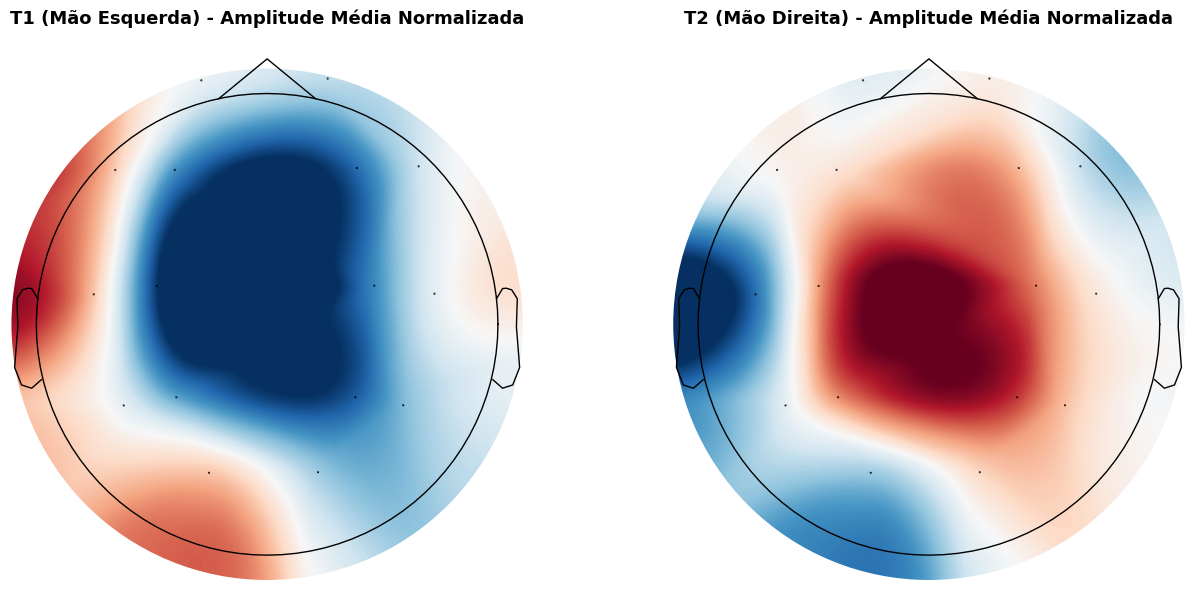

✓ Heatmaps cerebrais gerados com sucesso!



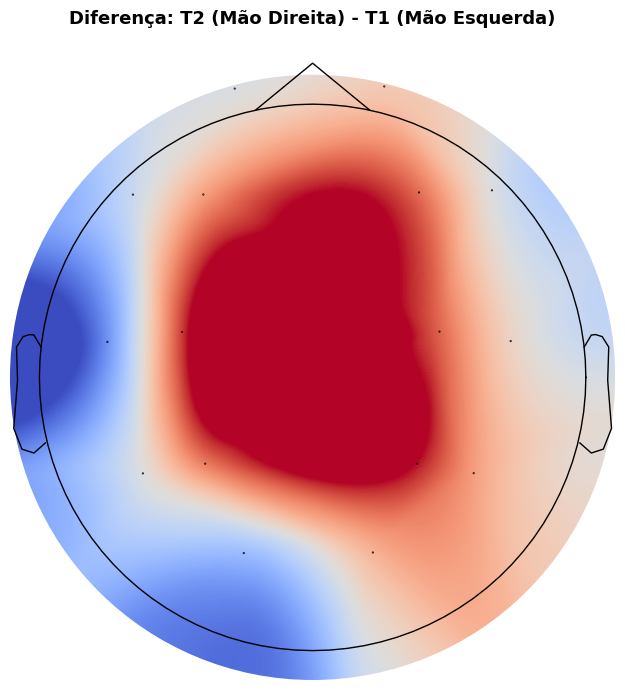

✓ Heatmap de diferença gerado!

📍 ANÁLISE ESPACIAL DOS CANAIS
--------------------------------------------------------------------------------

Amplitude por região (T1 - Mão Esquerda):
  Frontal (Fp1, Fp2, F3, F4, F7, F8): -0.0006
  Central (C3, C4): -0.0016
  Temporal (T7, T8): 0.0001
  Parietal (P3, P4): -0.0014
  Occipital (O1, O2): -0.0001

Amplitude por região (T2 - Mão Direita):
  Frontal (Fp1, Fp2, F3, F4, F7, F8): 0.0001
  Central (C3, C4): 0.0009
  Temporal (T7, T8): -0.0006
  Parietal (P3, P4): 0.0012
  Occipital (O1, O2): -0.0001

🧠 Interpretação Neurocientífica:
--------------------------------------------------------------------------------
  Frontal      | T1: -0.0006 | T2: +0.0001 | Diferença: +0.0007
  Central      | T1: -0.0016 | T2: +0.0009 | Diferença: +0.0026
  Temporal     | T1: +0.0001 | T2: -0.0006 | Diferença: -0.0007
  Parietal     | T1: -0.0014 | T2: +0.0012 | Diferença: +0.0026
  Occipital    | T1: -0.0001 | T2: -0.0001 | Diferença: -0.0000


In [22]:

# ==== VISUALIZAÇÃO DO HEATMAP CEREBRAL (MNE) ====

print("\n" + "="*80)
print("HEATMAP CEREBRAL: AMPLITUDE MÉDIA POR CLASSE (MNE)")
print("="*80)
print()

try:
    import mne
    from mne.viz import plot_topomap
    print("✓ MNE importado com sucesso!")
    
    # Definir posições dos eletrodos (Sistema 10-20 padrão)
    # Nessa ordem: Fp1, Fp2, F7, F8, F3, F4, T7, T8, C3, C4, P7, P8, P3, P4, O1, O2
    channel_labels = ['Fp1', 'Fp2', 'F7', 'F8', 'F3', 'F4', 'T7', 'T8', 'C3', 'C4', 'P7', 'P8', 'P3', 'P4', 'O1', 'O2']
    
    # Criar um objeto Info do MNE
    info = mne.create_info(ch_names=channel_labels, sfreq=FS, ch_types='eeg')
    
    # Carregar os pontos padrão do 10-20
    montage = mne.channels.make_standard_montage('standard_1020')
    info.set_montage(montage)
    
    # Preparar dados para o topomap
    # T1 (Mão Esquerda)
    data_t1 = mean_per_channel_class0
    
    # T2 (Mão Direita)
    data_t2 = mean_per_channel_class1
    
    print(f"Amplitude média T1: {data_t1}")
    print(f"Amplitude média T2: {data_t2}")
    print()
    
    # Criar figura com dois subplots (T1 e T2)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Calcular limites simétricos para melhor visualização
    vmax_t1 = np.abs(data_t1).max()
    vmax_t2 = np.abs(data_t2).max()
    vmax_global = max(vmax_t1, vmax_t2)
    
    # Plot T1 (Mão Esquerda)
    im1, _ = plot_topomap(
        data_t1,
        info,
        axes=axes[0],
        show=False,
        cmap='RdBu_r',
        vlim=(-vmax_global, vmax_global),
        contours=0,
        outlines='head'
    )
    axes[0].set_title('T1 (Mão Esquerda) - Amplitude Média Normalizada', fontsize=13, fontweight='bold')
    
    # Plot T2 (Mão Direita)
    im2, _ = plot_topomap(
        data_t2,
        info,
        axes=axes[1],
        show=False,
        cmap='RdBu_r',
        vlim=(-vmax_global, vmax_global),
        contours=0,
        outlines='head'
    )
    axes[1].set_title('T2 (Mão Direita) - Amplitude Média Normalizada', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Heatmaps cerebrais gerados com sucesso!")
    print()
    
    # Plotar diferença (T2 - T1)
    fig, ax = plt.subplots(figsize=(8, 7))
    
    diff_data = data_t2 - data_t1
    vmax_diff = np.abs(diff_data).max()
    
    im_diff, _ = plot_topomap(
        diff_data,
        info,
        axes=ax,
        show=False,
        cmap='coolwarm',
        vlim=(-vmax_diff, vmax_diff),
        contours=0,
        outlines='head'
    )
    ax.set_title('Diferença: T2 (Mão Direita) - T1 (Mão Esquerda)', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Heatmap de diferença gerado!")
    print()
    
    # Resumo espacial
    print("📍 ANÁLISE ESPACIAL DOS CANAIS")
    print("-" * 80)
    print("\nAmplitude por região (T1 - Mão Esquerda):")
    print(f"  Frontal (Fp1, Fp2, F3, F4, F7, F8): {data_t1[[0,1,4,5,2,3]].mean():.4f}")
    print(f"  Central (C3, C4): {data_t1[[8,9]].mean():.4f}")
    print(f"  Temporal (T7, T8): {data_t1[[6,7]].mean():.4f}")
    print(f"  Parietal (P3, P4): {data_t1[[12,13]].mean():.4f}")
    print(f"  Occipital (O1, O2): {data_t1[[14,15]].mean():.4f}")
    
    print("\nAmplitude por região (T2 - Mão Direita):")
    print(f"  Frontal (Fp1, Fp2, F3, F4, F7, F8): {data_t2[[0,1,4,5,2,3]].mean():.4f}")
    print(f"  Central (C3, C4): {data_t2[[8,9]].mean():.4f}")
    print(f"  Temporal (T7, T8): {data_t2[[6,7]].mean():.4f}")
    print(f"  Parietal (P3, P4): {data_t2[[12,13]].mean():.4f}")
    print(f"  Occipital (O1, O2): {data_t2[[14,15]].mean():.4f}")
    
    print()
    print("🧠 Interpretação Neurocientífica:")
    print("-" * 80)
    
    # Identificar região mais ativa por classe
    regions = {
        'Frontal': [0,1,4,5,2,3],
        'Central': [8,9],
        'Temporal': [6,7],
        'Parietal': [12,13],
        'Occipital': [14,15]
    }
    
    for region, indices in regions.items():
        mean_t1 = data_t1[indices].mean()
        mean_t2 = data_t2[indices].mean()
        print(f"  {region:12} | T1: {mean_t1:+.4f} | T2: {mean_t2:+.4f} | Diferença: {mean_t2-mean_t1:+.4f}")
    
    print("="*80)
    
except ImportError:
    print("⚠️ AVISO: MNE não está instalado!")
    print("Para usar essa visualização, execute: pip install mne")
    print()



HEATMAP CEREBRAL: CANAIS ESPECÍFICOS (F3, F4, T7, T8, C3, C4, O1, O2)

Canais selecionados: F3, F4, T7, T8, C3, C4, O1, O2

Amplitude média T1 (canais selecionados): [-0.00122492 -0.00154347  0.0004732  -0.00022518 -0.00195756 -0.00128868
  0.0005166  -0.00071368]
Amplitude média T2 (canais selecionados): [ 0.00028893  0.00066199 -0.00140731  0.00024408  0.00086726  0.00102191
 -0.00066632  0.00043689]



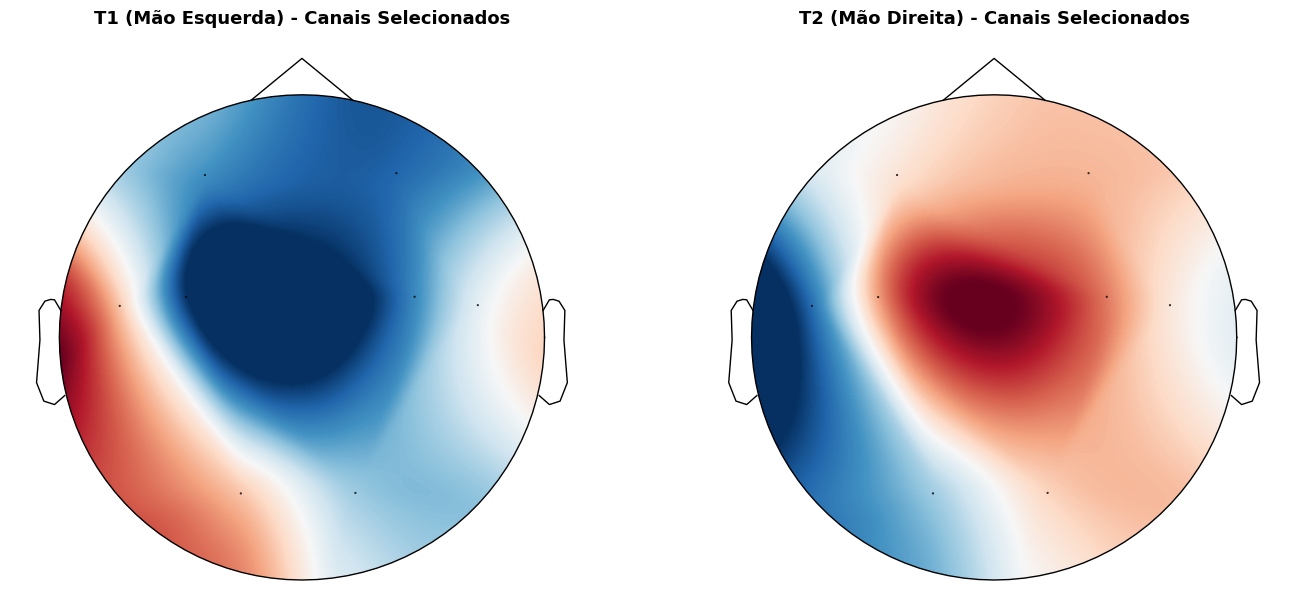

✓ Heatmaps cerebrais (canais selecionados) gerados com sucesso!



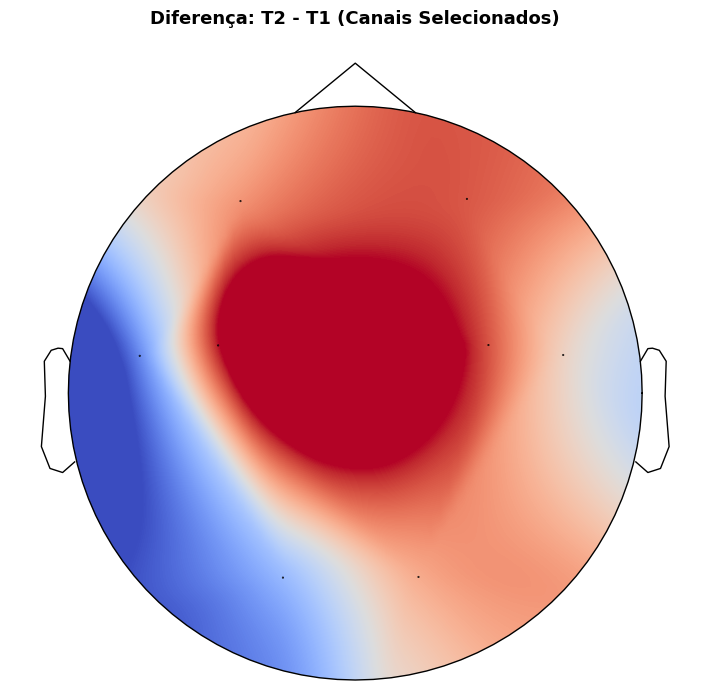

✓ Heatmap de diferença gerado!

📊 ANÁLISE DOS CANAIS SELECIONADOS
--------------------------------------------------------------------------------
Canal    T1 Amplitude       T2 Amplitude       Diferença          Cohen's d   
--------------------------------------------------------------------------------
F3       -0.001225       +0.000289       +0.001514       -0.0015
F4       -0.001543       +0.000662       +0.002205       -0.0022
T7       +0.000473       -0.001407       -0.001881       +0.0019
T8       -0.000225       +0.000244       +0.000469       -0.0005
C3       -0.001958       +0.000867       +0.002825       -0.0028
C4       -0.001289       +0.001022       +0.002311       -0.0023
O1       +0.000517       -0.000666       -0.001183       +0.0012
O2       -0.000714       +0.000437       +0.001151       -0.0012

🧠 Interpretação por Região (Canais Selecionados):
--------------------------------------------------------------------------------
  Motor Primário (C3/C4)    | T1: -0.0016

In [26]:
# ==== HEATMAP CEREBRAL - CANAIS SELECIONADOS (F3, F4, T7, T8, C3, C4, O1, O2) ====

print("\n" + "="*80)
print("HEATMAP CEREBRAL: CANAIS ESPECÍFICOS (F3, F4, T7, T8, C3, C4, O1, O2)")
print("="*80)
print()

try:
    import mne
    from mne.viz import plot_topomap
    
    # Canais selecionados (índices no sistema 10-20 padrão)
    # Ordem original: Fp1, Fp2, F7, F8, F3, F4, T7, T8, C3, C4, P7, P8, P3, P4, O1, O2
    #                  0    1    2   3   4   5   6   7   8   9  10  11  12  13  14  15
    selected_channels_idx = [4, 5, 6, 7, 8, 9, 14, 15]  # F3, F4, T7, T8, C3, C4, O1, O2
    selected_channel_names = ['F3', 'F4', 'T7', 'T8', 'C3', 'C4', 'O1', 'O2']
    
    print(f"Canais selecionados: {', '.join(selected_channel_names)}")
    print()
    
    # Criar um objeto Info do MNE apenas com os canais selecionados
    info_subset = mne.create_info(ch_names=selected_channel_names, sfreq=FS, ch_types='eeg')
    
    # Carregar os pontos padrão do 10-20
    montage_subset = mne.channels.make_standard_montage('standard_1020')
    info_subset.set_montage(montage_subset)
    
    # Extrair dados apenas dos canais selecionados
    data_t1_subset = mean_per_channel_class0[selected_channels_idx]
    data_t2_subset = mean_per_channel_class1[selected_channels_idx]
    
    print(f"Amplitude média T1 (canais selecionados): {data_t1_subset}")
    print(f"Amplitude média T2 (canais selecionados): {data_t2_subset}")
    print()
    
    # Criar figura com dois subplots (T1 e T2)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Calcular limites simétricos
    vmax_t1_sub = np.abs(data_t1_subset).max()
    vmax_t2_sub = np.abs(data_t2_subset).max()
    vmax_global_sub = max(vmax_t1_sub, vmax_t2_sub)
    
    # Plot T1 (Mão Esquerda)
    im1, _ = plot_topomap(
        data_t1_subset,
        info_subset,
        axes=axes[0],
        show=False,
        cmap='RdBu_r',
        vlim=(-vmax_global_sub, vmax_global_sub),
        contours=0,
        outlines='head'
    )
    axes[0].set_title('T1 (Mão Esquerda) - Canais Selecionados', fontsize=13, fontweight='bold')
    
    # Plot T2 (Mão Direita)
    im2, _ = plot_topomap(
        data_t2_subset,
        info_subset,
        axes=axes[1],
        show=False,
        cmap='RdBu_r',
        vlim=(-vmax_global_sub, vmax_global_sub),
        contours=0,
        outlines='head'
    )
    axes[1].set_title('T2 (Mão Direita) - Canais Selecionados', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Heatmaps cerebrais (canais selecionados) gerados com sucesso!")
    print()
    
    # Plotar diferença (T2 - T1)
    fig, ax = plt.subplots(figsize=(8, 7))
    
    diff_data_subset = data_t2_subset - data_t1_subset
    vmax_diff_sub = np.abs(diff_data_subset).max()
    
    im_diff, _ = plot_topomap(
        diff_data_subset,
        info_subset,
        axes=ax,
        show=False,
        cmap='coolwarm',
        vlim=(-vmax_diff_sub, vmax_diff_sub),
        contours=0,
        outlines='head'
    )
    ax.set_title('Diferença: T2 - T1 (Canais Selecionados)', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Heatmap de diferença gerado!")
    print()
    
    # Resumo dos canais selecionados
    print("📊 ANÁLISE DOS CANAIS SELECIONADOS")
    print("-" * 80)
    cohens_d_label = "Cohen's d"
    print(f"{'Canal':<8} {'T1 Amplitude':<18} {'T2 Amplitude':<18} {'Diferença':<18} {cohens_d_label:<12}")
    print("-" * 80)
    for i, (ch_idx, ch_name) in enumerate(zip(selected_channels_idx, selected_channel_names)):
        diff = data_t2_subset[i] - data_t1_subset[i]
        d = cohens_d[ch_idx]
        print(f"{ch_name:<8} {data_t1_subset[i]:>+.6f}       {data_t2_subset[i]:>+.6f}       {diff:>+.6f}       {d:>+.4f}")
    
    print()
    print("🧠 Interpretação por Região (Canais Selecionados):")
    print("-" * 80)
    
    # Regiões dos canais selecionados
    regions_subset = {
        'Motor Primário (C3/C4)': [4, 5],  # Índices em selected_channels_idx
        'Frontal (F3/F4)': [0, 1],
        'Temporal (T7/T8)': [2, 3],
        'Occipital (O1/O2)': [6, 7]
    }
    
    for region, local_indices in regions_subset.items():
        mean_t1 = data_t1_subset[local_indices].mean()
        mean_t2 = data_t2_subset[local_indices].mean()
        diff = mean_t2 - mean_t1
        print(f"  {region:25} | T1: {mean_t1:+.4f} | T2: {mean_t2:+.4f} | Δ: {diff:+.4f}")
    
    print()
    print("💡 Resumo Comparativo:")
    print("-" * 80)
    print(f"  Média T1 (todos canais selecionados): {data_t1_subset.mean():+.4f}")
    print(f"  Média T2 (todos canais selecionados): {data_t2_subset.mean():+.4f}")
    print(f"  Diferença geral (T2 - T1): {(data_t2_subset.mean() - data_t1_subset.mean()):+.4f}")
    
    print("="*80)
    
except ImportError:
    print("⚠️ AVISO: MNE não está instalado!")
    print("Para usar essa visualização, execute: pip install mne")
    print()


ANÁLISE DE DADOS: HardThinking/data/S002

Arquivos encontrados em C:\\Users\\Chari\\Documents\\dev\\Brainbridge\\HardThinking\\data\\S002:
  - P002_treino_20250923_153956.csv
  - P002_treino_20250924_151827.csv

Criando janelas (window_size=250, step=50)...
✓ X_raw shape: (49, 250, 16)
✓ y shape: (49,)
✓ Classes: (array([0, 1], dtype=int32), array([24, 25]))

Aplicando filtro bandpass (0.5-50 Hz)...
✓ X_bandpass shape: (49, 250, 16)

Split treino/teste:
  X_train: (39, 250, 16) | y_train classes: (array([0, 1], dtype=int32), array([19, 20]))
  X_test:  (10, 250, 16) | y_test classes:  (array([0, 1], dtype=int32), array([5, 5]))

Aplicando normalização z-score por canal...
✓ X_train_processed shape: (39, 250, 16)
✓ X_test_processed shape: (10, 250, 16)

✓ Estatísticas calculadas!

Gerando heatmaps cerebrais com canais: F3, F4, T7, T8, C3, C4, O1, O2

Amplitude média T1 (HardThinking): [ 0.0036775   0.00967883 -0.01434191 -0.00464705  0.00716432 -0.00022127
  0.00086201 -0.00270578]
Amp

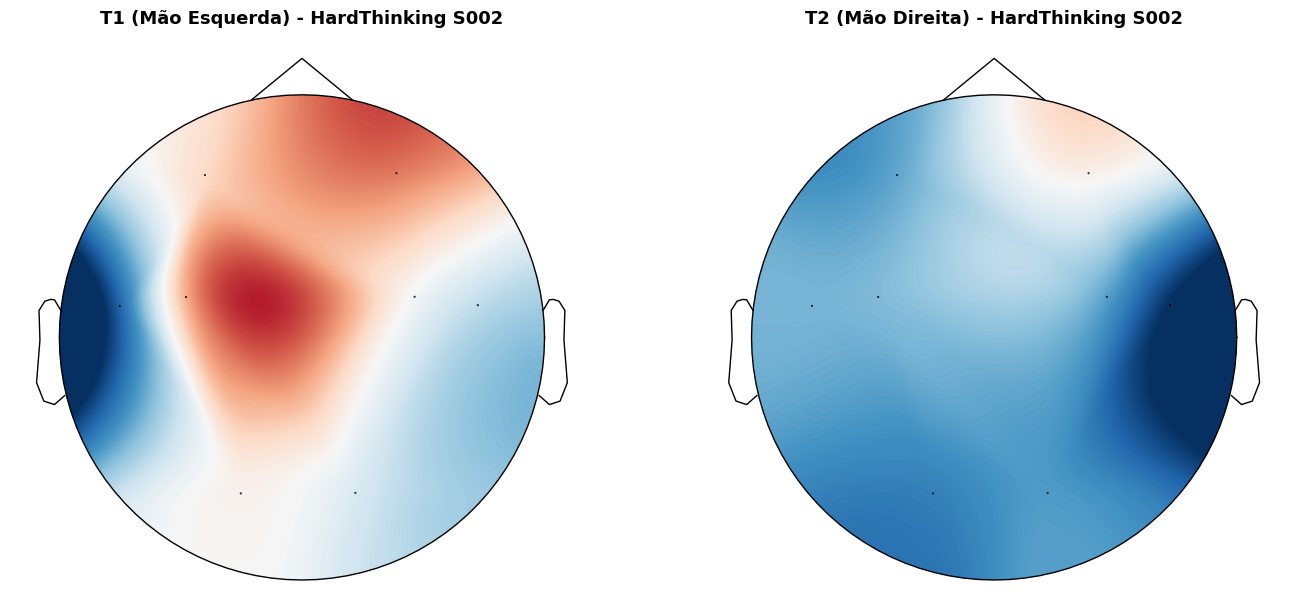

✓ Heatmaps T1 e T2 gerados!



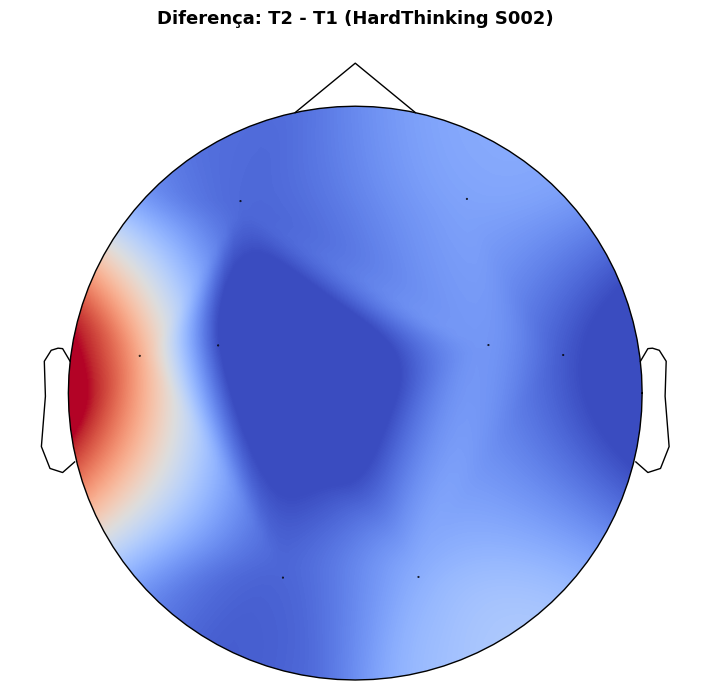

✓ Heatmap de diferença gerado!

📊 ANÁLISE DOS CANAIS SELECIONADOS (HardThinking S002)
--------------------------------------------------------------------------------
Canal    T1 Amplitude       T2 Amplitude       Diferença          Cohen's d   
--------------------------------------------------------------------------------
F3       +0.003677       -0.009614       -0.013291       +0.0139
F4       +0.009679       +0.000829       -0.008850       +0.0091
T7       -0.014342       -0.008729       +0.005613       -0.0059
T8       -0.004647       -0.018766       -0.014119       +0.0149
C3       +0.007164       -0.008246       -0.015410       +0.0162
C4       -0.000221       -0.010093       -0.009872       +0.0104
O1       +0.000862       -0.012688       -0.013550       +0.0143
O2       -0.002706       -0.010659       -0.007953       +0.0084

🧠 Interpretação por Região:
--------------------------------------------------------------------------------
  Motor Primário (C3/C4)    | T1: +0.0035 |

In [25]:

# ==== ANÁLISE COM DADOS DE HardThinking/data/S002 ====

print("\n" + "="*80)
print("ANÁLISE DE DADOS: HardThinking/data/S002")
print("="*80)
print()

# Garantir que os parâmetros de configuração estão definidos
if 'WINDOW_SIZE' not in locals():
    WINDOW_SIZE = 250
    STEP = 50
    FS = 125.0
    TEST_SIZE = 0.2
    RANDOM_SEED = 42

# Caminho dos dados
from pathlib import Path
import glob
HARDTHINKING_DATA_PATH = r"C:\\Users\\Chari\\Documents\\dev\\Brainbridge\\HardThinking\\data\\S002"
PATTERN_HT = "*.csv"

# Buscar arquivos CSV
csv_files_ht = sorted(glob.glob(str(Path(HARDTHINKING_DATA_PATH) / PATTERN_HT)))
print(f"Arquivos encontrados em {HARDTHINKING_DATA_PATH}:")
for f in csv_files_ht:
    print(f"  - {Path(f).name}")
print()

if not csv_files_ht:
    print("❌ Nenhum arquivo CSV encontrado!")
else:
    # Criar janelas usando os mesmos parâmetros
    print(f"Criando janelas (window_size={WINDOW_SIZE}, step={STEP})...")
    X_raw_ht, y_ht = create_windows_openbci(csv_files_ht, fs=FS, window_size=WINDOW_SIZE, step=STEP)
    print(f"✓ X_raw shape: {X_raw_ht.shape}")
    print(f"✓ y shape: {y_ht.shape}")
    print(f"✓ Classes: {np.unique(y_ht, return_counts=True)}")
    print()
    
    if len(X_raw_ht) > 0:
        # Aplicar filtro bandpass
        print(f"Aplicando filtro bandpass (0.5-50 Hz)...")
        X_bandpass_ht = preprocess_X_bandpass_only(X_raw_ht, fs=FS)
        print(f"✓ X_bandpass shape: {X_bandpass_ht.shape}")
        print()
        
        # Split treino/teste
        X_train_ht, X_test_ht, y_train_ht, y_test_ht = train_test_split(
            X_bandpass_ht, y_ht, test_size=TEST_SIZE, stratify=y_ht, random_state=RANDOM_SEED
        )
        
        print(f"Split treino/teste:")
        print(f"  X_train: {X_train_ht.shape} | y_train classes: {np.unique(y_train_ht, return_counts=True)}")
        print(f"  X_test:  {X_test_ht.shape} | y_test classes:  {np.unique(y_test_ht, return_counts=True)}")
        print()
        
        # Normalização z-score
        print(f"Aplicando normalização z-score por canal...")
        mu_ht, sd_ht = fit_channel_stats(X_train_ht)
        X_train_processed_ht = apply_channel_stats(X_train_ht, mu_ht, sd_ht)
        X_test_processed_ht = apply_channel_stats(X_test_ht, mu_ht, sd_ht)
        
        print(f"✓ X_train_processed shape: {X_train_processed_ht.shape}")
        print(f"✓ X_test_processed shape: {X_test_processed_ht.shape}")
        print()
        
        # Combinar dados para análise
        X_combined_ht = np.vstack([X_train_processed_ht, X_test_processed_ht])
        y_combined_ht = np.hstack([y_train_ht, y_test_ht])
        
        # Calcular estatísticas por canal e classe
        X_class0_ht = X_combined_ht[y_combined_ht == 0]  # T1 = Mão Esquerda
        X_class1_ht = X_combined_ht[y_combined_ht == 1]  # T2 = Mão Direita
        
        mean_per_channel_class0_ht = X_class0_ht.reshape(-1, X_class0_ht.shape[-1]).mean(axis=0)
        mean_per_channel_class1_ht = X_class1_ht.reshape(-1, X_class1_ht.shape[-1]).mean(axis=0)
        
        std_per_channel_class0_ht = X_class0_ht.reshape(-1, X_class0_ht.shape[-1]).std(axis=0)
        std_per_channel_class1_ht = X_class1_ht.reshape(-1, X_class1_ht.shape[-1]).std(axis=0)
        
        # Cohen's d
        cohens_d_ht = (mean_per_channel_class0_ht - mean_per_channel_class1_ht) / np.sqrt(
            (std_per_channel_class0_ht**2 + std_per_channel_class1_ht**2) / 2 + 1e-8
        )
        
        # Correlação
        correlations_ht = []
        for ch in range(X_combined_ht.shape[2]):
            X_ch_mean = X_combined_ht[:, :, ch].mean(axis=1)
            corr = np.corrcoef(X_ch_mean, y_combined_ht)[0, 1]
            correlations_ht.append(corr)
        correlations_ht = np.array(correlations_ht)
        
        print("✓ Estatísticas calculadas!")
        print()
        
        # ==== HEATMAP CEREBRAL COM CANAIS SELECIONADOS ====
        try:
            import mne
            from mne.viz import plot_topomap
            
            # Canais selecionados
            selected_channels_idx = [4, 5, 6, 7, 8, 9, 14, 15]  # F3, F4, T7, T8, C3, C4, O1, O2
            selected_channel_names = ['F3', 'F4', 'T7', 'T8', 'C3', 'C4', 'O1', 'O2']
            
            print(f"Gerando heatmaps cerebrais com canais: {', '.join(selected_channel_names)}")
            print()
            
            # Criar Info do MNE
            info_subset_ht = mne.create_info(ch_names=selected_channel_names, sfreq=FS, ch_types='eeg')
            montage_subset_ht = mne.channels.make_standard_montage('standard_1020')
            info_subset_ht.set_montage(montage_subset_ht)
            
            # Extrair dados dos canais selecionados
            data_t1_subset_ht = mean_per_channel_class0_ht[selected_channels_idx]
            data_t2_subset_ht = mean_per_channel_class1_ht[selected_channels_idx]
            
            print(f"Amplitude média T1 (HardThinking): {data_t1_subset_ht}")
            print(f"Amplitude média T2 (HardThinking): {data_t2_subset_ht}")
            print()
            
            # Criar figura com T1 e T2
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            
            vmax_t1_sub_ht = np.abs(data_t1_subset_ht).max()
            vmax_t2_sub_ht = np.abs(data_t2_subset_ht).max()
            vmax_global_sub_ht = max(vmax_t1_sub_ht, vmax_t2_sub_ht)
            
            # Plot T1
            im1, _ = plot_topomap(
                data_t1_subset_ht,
                info_subset_ht,
                axes=axes[0],
                show=False,
                cmap='RdBu_r',
                vlim=(-vmax_global_sub_ht, vmax_global_sub_ht),
                contours=0,
                outlines='head'
            )
            axes[0].set_title('T1 (Mão Esquerda) - HardThinking S002', fontsize=13, fontweight='bold')
            
            # Plot T2
            im2, _ = plot_topomap(
                data_t2_subset_ht,
                info_subset_ht,
                axes=axes[1],
                show=False,
                cmap='RdBu_r',
                vlim=(-vmax_global_sub_ht, vmax_global_sub_ht),
                contours=0,
                outlines='head'
            )
            axes[1].set_title('T2 (Mão Direita) - HardThinking S002', fontsize=13, fontweight='bold')
            
            plt.tight_layout()
            plt.show()
            
            print("✓ Heatmaps T1 e T2 gerados!")
            print()
            
            # Plotar diferença
            fig, ax = plt.subplots(figsize=(8, 7))
            
            diff_data_subset_ht = data_t2_subset_ht - data_t1_subset_ht
            vmax_diff_sub_ht = np.abs(diff_data_subset_ht).max()
            
            im_diff, _ = plot_topomap(
                diff_data_subset_ht,
                info_subset_ht,
                axes=ax,
                show=False,
                cmap='coolwarm',
                vlim=(-vmax_diff_sub_ht, vmax_diff_sub_ht),
                contours=0,
                outlines='head'
            )
            ax.set_title('Diferença: T2 - T1 (HardThinking S002)', fontsize=13, fontweight='bold')
            
            plt.tight_layout()
            plt.show()
            
            print("✓ Heatmap de diferença gerado!")
            print()
            
            # Análise dos canais selecionados
            print("📊 ANÁLISE DOS CANAIS SELECIONADOS (HardThinking S002)")
            print("-" * 80)
            cohens_header = "Cohen's d"
            print(f"{'Canal':<8} {'T1 Amplitude':<18} {'T2 Amplitude':<18} {'Diferença':<18} {cohens_header:<12}")
            print("-" * 80)
            for i, (ch_idx, ch_name) in enumerate(zip(selected_channels_idx, selected_channel_names)):
                diff = data_t2_subset_ht[i] - data_t1_subset_ht[i]
                d = cohens_d_ht[ch_idx]
                print(f"{ch_name:<8} {data_t1_subset_ht[i]:>+.6f}       {data_t2_subset_ht[i]:>+.6f}       {diff:>+.6f}       {d:>+.4f}")
            
            print()
            print("🧠 Interpretação por Região:")
            print("-" * 80)
            
            regions_subset_ht = {
                'Motor Primário (C3/C4)': [4, 5],
                'Frontal (F3/F4)': [0, 1],
                'Temporal (T7/T8)': [2, 3],
                'Occipital (O1/O2)': [6, 7]
            }
            
            for region, local_indices in regions_subset_ht.items():
                mean_t1 = data_t1_subset_ht[local_indices].mean()
                mean_t2 = data_t2_subset_ht[local_indices].mean()
                diff = mean_t2 - mean_t1
                print(f"  {region:25} | T1: {mean_t1:+.4f} | T2: {mean_t2:+.4f} | Δ: {diff:+.4f}")
            
            print()
            print("💡 Resumo Comparativo:")
            print("-" * 80)
            print(f"  Média T1 (HardThinking): {data_t1_subset_ht.mean():+.4f}")
            print(f"  Média T2 (HardThinking): {data_t2_subset_ht.mean():+.4f}")
            print(f"  Diferença geral (T2 - T1): {(data_t2_subset_ht.mean() - data_t1_subset_ht.mean()):+.4f}")
            
            print("="*80)
            
        except ImportError:
            print("⚠️ AVISO: MNE não está instalado!")
            print("Para usar essa visualização, execute: pip install mne")
